In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
df=pd.read_csv(r'D:\Shorya\python\EDA Practice csv\hotel_bookings.csv')
df.sample(5)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
61957,City Hotel,1,193,2016,December,53,29,0,3,2,...,No Deposit,9.0,NaN,0,Transient,160.2,0,0,Canceled,2016-07-05
4015,Resort Hotel,1,111,2016,February,7,12,0,2,2,...,Non Refund,38.0,NaN,0,Transient,70.0,0,0,Canceled,2016-01-26
37237,Resort Hotel,0,24,2017,June,23,8,0,3,2,...,No Deposit,250.0,NaN,0,Transient,135.0,0,0,Check-Out,2017-06-11
29615,Resort Hotel,0,10,2016,October,44,29,2,1,2,...,No Deposit,NaN,NaN,0,Transient,38.0,0,2,Check-Out,2016-11-01
81182,City Hotel,0,68,2015,December,49,2,0,4,2,...,No Deposit,28.0,NaN,0,Transient,60.0,0,0,Check-Out,2015-12-06


In [3]:
df.shape

(119390, 32)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

# Literature Review: Revenue Management, Demand Forecasting, and Cancellation Prediction in the Hospitality Industry

### 1. Introduction to the Hospitality Data Landscape
The modern hospitality and tourism industries generate massive volumes of transactional data via Property Management Systems (PMS) and Central Reservation Systems (CRS) (Yoo et al., 2023). Historically, empirical research in hospitality analytics was restricted by the proprietary nature of corporate data, leaving a significant gap in reproducible, micro-level data science applications (Antonio et al., 2019). This limitation was substantially mitigated by Antonio, de Almeida, and Nunes (2019), who published the Hotel Booking Demand Dataset.

This real-world dataset contains 119,390 individual booking observations spanning from July 1, 2015, to August 31, 2017, across two distinct property types in Portugal: a Resort Hotel ($H1$) and a City Hotel ($H2$) (Antonio et al., 2019). The 31 operational variables provided include temporal demand metrics (lead_time, arrival_date_year), operational dynamics (adr, deposit_type, assigned_room_type), and customer behavioral indicators (total_of_special_requests, customer_type), making it the premier benchmark dataset for Exploratory Data Analysis (EDA) and predictive modeling in hospitality analytics (Chen, 2025; Yoo et al., 2023).

### 2. The Operational and Economic Impact of Cancellations
In hospitality revenue management, a hotel room is categorized as a highly perishable asset; if a room remains vacant for a night, that potential revenue is irrevocably lost (Gómez-Talal et al., 2025). Operational uncertainty is significantly compounded by booking cancellations, which typically affect between 10% and 30% of total reservations, translating to estimated revenue losses of up to 20% for hospitality enterprises (Gómez-Talal et al., 2025).

The widespread adoption of Online Travel Agencies (OTAs) and the industry-wide shift toward flexible, low-risk cancellation policies have altered consumer behavior, facilitating a phenomenon known as "cancel-and-rebook" (Kmiecik, 2026). Guests frequently abuse free-cancellation windows to cancel an existing reservation and immediately rebook the same room at a lower rate if prices drop, causing significant revenue leakage and distorting true market demand signals (Kmiecik, 2026). To counteract these uncertainties, hoteliers historically relied on restrictive non-refundable deposit policies or aggressive overbooking strategies (António, 2019). However, overbooking introduces severe reputational risks and customer dissatisfaction when capacity is exceeded, while strict deposit policies can deter baseline demand (Chen, 2025). Consequently, the capacity to perform descriptive exploratory analytics and build accurate cancellation forecasting models is essential for optimizing contemporary revenue management systems (Yoo et al., 2023).

### 3. Key Behavioral and Operational Drivers of Booking Status
Extensive literature utilizing the Antonio et al. (2019) dataset identifies several core feature subsets as critical determinants of a booking's final status (is_canceled):

Lead Time: The duration between the booking date and the arrival date (lead_time) consistently emerges across the literature as one of the strongest predictors of cancellation propensity (Gómez-Talal et al., 2025). Longer lead times inherently introduce higher temporal uncertainty, increasing the probability that a customer's travel plans will change or that they will find a more competitive alternative online.

Pricing Dynamics and Seasonality: The Average Daily Rate (adr) coupled with arrival timelines (arrival_date_month, arrival_date_week_number) captures the macroeconomic forces of demand elasticity. Demand patterns vary drastically between families and non-families based on school holiday calendars, and price sensitivity dynamically shifts across different seasons and room tiers (Lin, 2025).

Deposit and Operational Safeguards: Features such as deposit_type (e.g., Non Refund, No Deposit) and the allocation of required parking spaces (required_car_parking_spaces) exhibit strong non-linear relationships with cancellation rates. Bookings requiring parking spaces or structural modifications rarely cancel, indicating high-intent travel (Chen, 2025).

Hotel Cohort Variations: A crucial theme in recent literature is the behavioral divergence between hotel types. Comparative studies indicate that while unified models offer robust baseline generalizations, city hotels and resort hotels exhibit distinct operational structures—city hotels handle shorter, high-turnover business segments, whereas resort hotels manage highly seasonal, extended leisure stays (Chen, 2025).

### 4. Methodological Evolution: From Descriptive EDA to Predictive AI
The methodological paradigm in hospitality demand modeling has evolved rapidly:

[Traditional Statistical Models] ---> [Machine Learning Ensembles] ---> [Explainable AI & Deep Learning]
    (Omitted Micro-behaviors)           (High Accuracy Black-Box)            (SHAP, Multimodal, CLV)
Historically, the industry relied on aggregated time-series frameworks and traditional parametric statistical methods (e.g., logistic regression) to estimate average cancellation rates (Yoo et al., 2023). While useful for high-level macro-forecasting, these approaches treated customer segments as a homogeneous entity and failed to capture granular, micro-level operational nuances (Lin, 2025; Yoo et al., 2023).

Over the past decade, the integration of advanced machine learning algorithms has vastly improved predictive precision. Ensemble techniques—specifically tree-based classifiers like Random Forest and Gradient Boosting Machines (XGBoost)—demonstrate exceptional robustness when handling the mixed-data types, non-linear dependencies, and class imbalances inherent in the Antonio et al. dataset (Chen, 2025; Gómez-Talal et al., 2025). Recent milestones in the field have pushed boundaries further by applying Deep Learning architectures, such as Long Short-Term Memory (LSTM) networks and Policy-Enhanced Reinforcement Learning, to model dynamic, temporal variations in booking queues (Xiao et al., 2024).  

The current frontier of research addresses the "black box" limitation of these advanced algorithms. Contemporary literature heavily emphasizes Explainable Artificial Intelligence (XAI) frameworks (using SHAP or LIME) to isolate exactly why a customer is flagged to cancel (Gómez-Talal et al., 2025). Furthermore, researchers are now blending structured transactional PMS data with unstructured text analytics (such as guest review sentiment) to build multimodal deep learning architectures capable of predicting long-term Customer Lifetime Value (CLV) alongside immediate cancellation risks (Nikolić, 2026).



# Dataset Schema & Feature Definitions
This dataset contains booking information for a City Hotel and a Resort Hotel, tracking 31 operational, temporal, and behavioral variables across 119,390 observations.

##**1. Target Variable**
**is_canceled (int64)**: Value indicating if the booking was canceled (1) or not (0).

## 2. Temporal & Arrival Features
**lead_time (int64)**: Number of days that elapsed between the entering date of the booking into the PMS and the arrival date.

**arrival_date_year (int64)**: Year of arrival date (2015, 2016, or 2017).

**arrival_date_month (object)**: Month of arrival date (January to December).

**arrival_date_week_number (int64)**: Week number of the year for arrival date.

**arrival_date_day_of_month (int64)**: Day of the month of arrival date.

**reservation_status_date (object)**: Date at which the last status was recorded. Used in conjunction with reservation_status.

## 3. Stay Duration & Composition
**stays_in_weekend_nights (int64)**: Number of weekend nights (Saturday or Sunday) the guest stayed or booked to stay at the hotel.  

**stays_in_week_nights (int64)**: Number of week nights (Monday to Friday) the guest stayed or booked to stay at the hotel.  

**adults (int64)**: Number of adults.  

**children (float64)**: Number of children (contains 4 missing values).  

**babies (int64)**: Number of babies.

## 4. Operational & Booking Details
**hotel (object)**: Hotel type (Resort Hotel or City Hotel).

**meal (object)**: Type of meal booked (e.g., BB - Bed & Breakfast, HB - Half Board, FB - Full Board, SC - Self Catering).

**country (object)**: Country of origin of the guest (contains 488 missing values).

**market_segment (object)**: Market segment designation (e.g., TA/TO - Travel Agents/Tour Operators, Corporate, Direct, Groups).

**distribution_channel (object)**: Booking distribution channel (e.g., TA/TO, Direct, Corporate).

**reserved_room_type (object)**: Code of room type reserved. Code is presented instead of designation for anonymity.

**assigned_room_type (object)**: Code for the type of room assigned to the booking. (Note: May differ from reserved_room_type due to operational reasons/upgrades).

**booking_changes (int64)**: Number of changes/amendments made to the booking from the moment the booking was entered on the PMS until the moment of check-in or cancellation.

**deposit_type (object)**: Indication on if the customer made a deposit to guarantee the booking (No Deposit, Non Refund, Refundable).

**agent (float64)**: ID of the travel agency that made the booking (contains 16,340 missing values).

**company (float64)**: ID of the company/entity that made the booking or responsible for paying the rooms (contains 112,593 missing values).

**days_in_waiting_list (int64)**: Number of days the booking was on the waiting list before it was confirmed to the customer.

**customer_type (object)**: Type of booking (e.g., Transient, Transient-Party, Contract, Group).

**adr (float64): Average Daily Rate** (calculated by dividing the sum of all lodging transactions by the total number of staying nights).

**required_car_parking_spaces (int64)**: Number of car parking spaces required by the customer.

**total_of_special_requests (int64)**: Number of special requests made by the customer (e.g., twin bed, high floor).

## 5. Guest History
**is_repeated_guest (int64):** Value indicating if the booking name was from a repeated guest (1) or not (0).  

**previous_cancellations (int64)**: Number of previous bookings that were cancelled by the customer prior to the current booking.  

**previous_bookings_not_canceled (int64)**: Number of previous bookings not cancelled by the customer prior to the current booking.  

## **6. Post-Booking / Outcome Variable**
**reservation_status (object)**: Reservation last status (Check-Out, Canceled, No-Show).

## Source:
https://doi.org/10.1016/j.dib.2018.11.126

# Problem statement
In the hospitality industry, empty rooms represent perishable inventory and irreversible revenue loss. If a hotel room sits vacant for a single night, the revenue it could have generated is gone forever.

To mitigate this, hotels allow customers to book months in advance. However, this creates a major operational vulnerability: uncaptured cancellations. When a guest cancels late or simply fails to show up (a "No-Show"), the hotel is left with a vacant room that could have been sold to another paying customer.

To fight this, hoteliers traditionally use two blunt instruments:

Overbooking: Intentionally selling more rooms than the hotel actually has, banking on the statistical likelihood that some guests will cancel. The risk: If fewer people cancel than expected, the hotel faces severe financial penalties and reputational damage from having to walk "walk" premium guests to a competitor.

Restrictive Policies: Enforcing rigid, non-refundable deposit fees. The risk: This alienates customers and drives them straight to competitors with flexible booking policies.

Professional Problem Statement
Optimizing Asset Utilization and Revenue Management in the Hospitality Industry via Predictive Cancellation Modeling and Demand Forecasting

Context
Modern Hospitality Revenue Management Systems (RMS) rely heavily on advance-booking windows to forecast demand and dynamically optimize Average Daily Rates (ADR). However, the widespread adoption of flexible Online Travel Agency (OTA) cancellation policies has triggered high consumer volatility, leading to significant revenue leakage from unpredictable booking cancellations and "cancel-and-rebook" behaviors.

The Challenge
Using historical Property Management System (PMS) transaction data from two distinct lodging properties (a City Hotel and a Resort Hotel), the core challenge is twofold:

Descriptive Bottleneck: Isolating the latent operational, temporal, and customer behavioral drivers—such as long lead times, distribution channel friction, and deposit structures—that correlate with a high propensity to cancel.

Predictive Bottleneck: Developing a highly accurate, non-linear machine learning framework capable of predicting the probability of an individual reservation cancellation (is_canceled) prior to the arrival date, without relying on post-booking status indicators.

Business & Operational Objective
The ultimate objective is to transition from reactive, intuition-based overbooking strategies to proactive, data-driven revenue management. By accurately flagging high-risk reservations, hotel operators can selectively implement targeted retention campaigns, dynamically adjust dynamic pricing thresholds, optimize capacity allocation, and safely overbook volatile segments. This directly maximizes the Net Revenue Per Available Room (NetRevPAR) while minimizing both uncaptured room vacancies and the costly reputational risks associated with over-capacity compensation.

### Finding missing value

In [10]:
df.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

**null values observed in children, country, company and agaent columns**

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

## Univariate analysis

In [14]:
sns.set_style()
sns.set_theme(style='darkgrid')

### hotel

In [16]:
df['hotel'].unique()

array(['Resort Hotel', 'City Hotel'], dtype=object)

<Axes: xlabel='hotel', ylabel='count'>

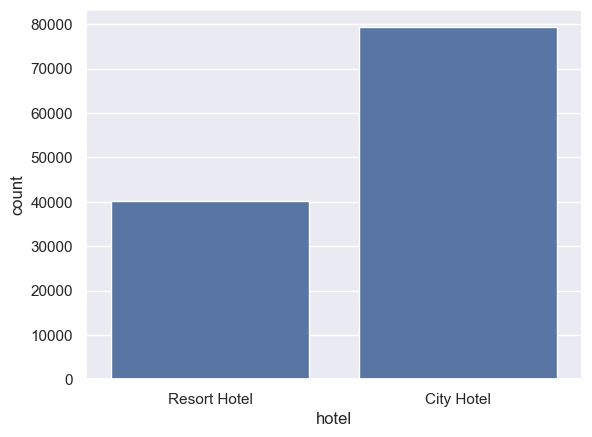

In [17]:
sns.countplot(x='hotel',data=df)

In [18]:
df['hotel'].value_counts(normalize=True)*100

hotel
City Hotel      66.446101
Resort Hotel    33.553899
Name: proportion, dtype: float64

City Hotels dominate the dataset with 66.45% of all bookings, while Resort Hotels account for 33.55%, indicating that the data is primarily driven by urban travel behavior rather than leisure tourism.

This pattern suggests stronger demand for City Hotels due to business travel, conferences, transit stays, and city tourism, which typically generate consistent year-round bookings. Such hotels are also more likely to experience shorter stays, higher booking frequency, and potentially higher cancellation rates because business plans often change.

On the other hand, Resort Hotels represent a smaller but important segment linked to vacation and seasonal travel. This category is likely to show longer stay durations, earlier bookings, and seasonal spikes during holidays and peak tourism periods.

The clear imbalance between hotel types also indicates that customer behavior, pricing trends, booking channels, and cancellation patterns may differ significantly across the two categories. As a result, the `hotel` feature is expected to play a major role in downstream analysis and predictive modeling.


### is_canceled

In [21]:
df['is_canceled'].unique()

array([0, 1], dtype=int64)

<Axes: xlabel='is_canceled', ylabel='count'>

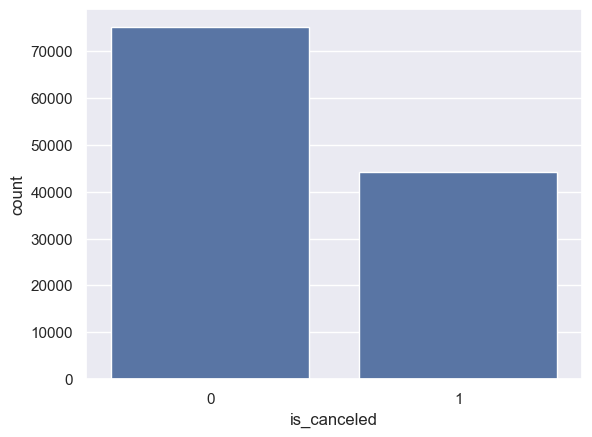

In [22]:
sns.countplot(x='is_canceled',data=df)

In [23]:
df['is_canceled'].value_counts(normalize=True)*100

is_canceled
0    62.958372
1    37.041628
Name: proportion, dtype: float64

The cancellation distribution shows that 62.96% of bookings were successfully retained, while 37.04% were canceled. Although most customers completed their bookings, the cancellation rate is significantly high, meaning more than 1 in every 3 reservations did not convert into actual stays.

This pattern highlights a major operational challenge for the hotel industry, as high cancellation rates can directly impact revenue forecasting, room allocation, staffing, and inventory management.

The elevated cancellation behavior may be associated with factors such as long lead times, flexible cancellation policies, OTA bookings, price sensitivity, or changing travel plans. It also suggests that certain customer segments or hotel types may contribute disproportionately to cancellations.

From a data science perspective, `is_canceled` becomes a highly important target variable for predictive modeling, as identifying cancellation patterns can help hotels optimize pricing strategies, reduce revenue loss, and improve booking management systems.


### lead_time

<Axes: xlabel='lead_time', ylabel='Count'>

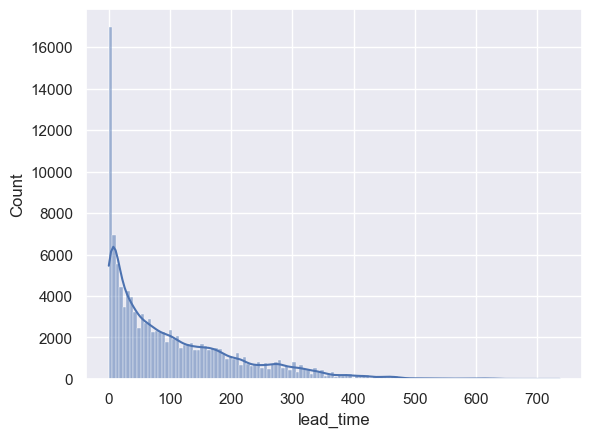

In [26]:
sns.histplot(x='lead_time',data=df,kde=True)

In [27]:
df['lead_time'].describe()

count    119390.000000
mean        104.011416
std         106.863097
min           0.000000
25%          18.000000
50%          69.000000
75%         160.000000
max         737.000000
Name: lead_time, dtype: float64

<Axes: xlabel='lead_time'>

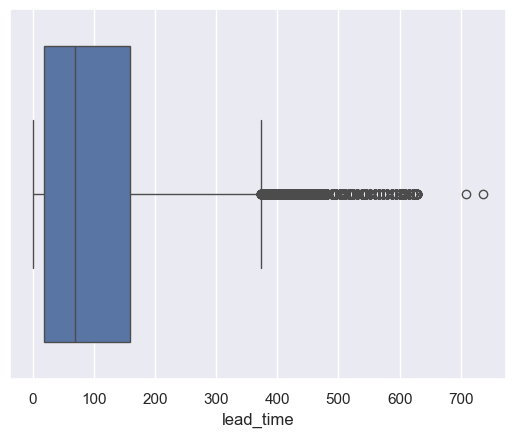

In [28]:
sns.boxplot(x='lead_time',data=df)

The `lead_time` variable shows extremely high variability in booking behavior, with an average lead time of 104 days and a very large standard deviation of 106.86 days. This indicates that customers book rooms across a wide range of time horizons, from same-day bookings to reservations made nearly two years in advance.

The distribution appears strongly right-skewed, as the mean (104) is substantially higher than the median (69). This suggests the presence of a significant number of very early bookings that pull the average upward.

Key booking patterns emerge from the quartiles:

* 25% of customers book within 18 days of arrival, indicating a large segment of short-notice travelers.
* 50% of bookings occur within 69 days.
* 75% of customers book within 160 days, showing that most reservations are made several months in advance.

The maximum lead time of 737 days highlights the existence of extreme long-term planners, likely linked to vacations, events, or group travel bookings.

From a business perspective, long lead times are often associated with higher cancellation probability because travel plans are more likely to change over extended periods. Short lead times, meanwhile, may indicate urgent, business, or last-minute travel behavior.

Overall, `lead_time` appears to be a highly influential feature that can strongly impact cancellation behavior, customer segmentation, demand forecasting, and revenue management strategies.


### **arrival_date_year**

In [31]:
df['arrival_date_year'].unique()

array([2015, 2016, 2017], dtype=int64)

<Axes: xlabel='arrival_date_year', ylabel='count'>

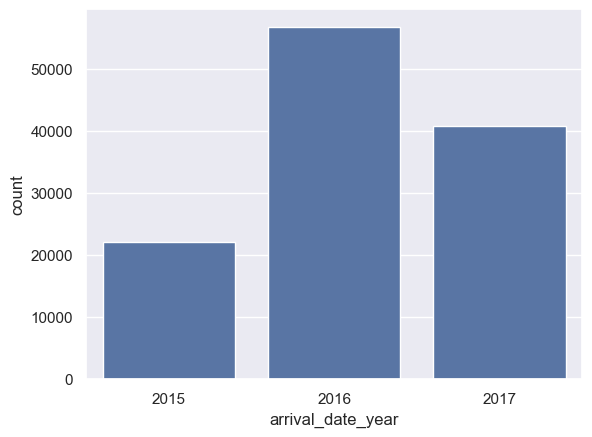

In [32]:
sns.countplot(x='arrival_date_year',data=df)

In [33]:
df['arrival_date_year'].value_counts(normalize=True)*100

arrival_date_year
2016    47.497278
2017    34.079069
2015    18.423654
Name: proportion, dtype: float64

In [34]:
import pandas as pd

# Define the chronological order of months to ensure proper alignment
month_order = [
    'January', 'February', 'March', 'April', 'May', 'June', 
    'July', 'August', 'September', 'October', 'November', 'December'
]

# Ensure the column is categorical with explicit ordering
df['arrival_date_month'] = pd.Categorical(df['arrival_date_month'], categories=month_order, ordered=True)

# Generate a cross-tabulation normalized by column (year) to show proportions cleanly
monthly_trend_pct = pd.crosstab(
    index=df['arrival_date_month'], 
    columns=df['arrival_date_year'], 
    normalize='columns'
) * 100

# Style the output with a background gradient for instant scannability
monthly_trend_pct.style.background_gradient(cmap='Blues').format("{:.2f}%")

arrival_date_year,2015,2016,2017
arrival_date_month,,,
January,0.00%,3.96%,9.05%
February,0.00%,6.86%,10.27%
March,0.00%,8.51%,12.22%
April,0.00%,9.57%,13.91%
May,0.00%,9.66%,15.52%
June,0.00%,9.33%,13.88%
July,12.62%,8.06%,13.06%
August,17.68%,8.93%,12.10%
September,23.25%,9.51%,0.00%


The booking distribution across years shows a clear upward trend in hotel demand over time. The year 2016 accounts for the largest share of bookings at 47.50%, followed by 2017 with 34.08%, while 2015 contributes only 18.42% of total reservations.

This pattern suggests that hotel activity increased significantly after 2015, indicating possible business growth, higher tourism demand, improved online booking adoption, or expanded hotel operations during later years.

The relatively lower share for 2015 may also indicate partial-year data collection, which is common in hospitality datasets and should be verified during analysis.

The dominance of 2016 and 2017 implies that more recent booking behavior heavily influences the dataset, meaning trends such as cancellations, pricing, customer preferences, and seasonal demand may be more reflective of these later years.

From an analytical perspective, `arrival_date_year` may capture temporal trends and changing customer behavior over time, making it potentially useful for seasonality analysis, trend forecasting, and time-based modeling.


### arrival_date_month

C:\Users\kavit\AppData\Local\Temp\ipykernel_1272\3807864202.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='arrival_date_month',data=df,palette='viridis')


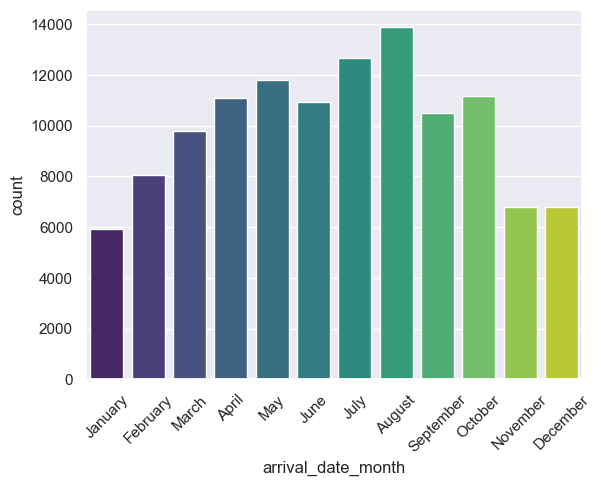

In [37]:
sns.countplot(x='arrival_date_month',data=df,palette='viridis')
plt.xticks(rotation=45)
plt.show()

In [38]:
df['arrival_date_month'].value_counts(normalize=True)*100

arrival_date_month
August       11.623252
July         10.604741
May           9.876037
October       9.347517
April         9.288048
June          9.162409
September     8.801407
March         8.203367
February      6.757685
November      5.690594
December      5.678868
January       4.966078
Name: proportion, dtype: float64

The monthly booking distribution reveals clear seasonal trends in hotel demand. August accounts for the highest proportion of bookings (11.62%), followed by July (10.60%) and May (9.88%), indicating that hotel activity peaks during the summer and vacation season.

A consistently high concentration of bookings from April to October suggests a prolonged high-demand period driven by tourism, holidays, and favorable travel conditions. July and August especially appear to be peak travel months, likely associated with leisure and family vacations.

In contrast, January records the lowest share of bookings (4.97%), while November and December also show relatively lower demand, indicating an off-season period with reduced travel activity.

The distribution remains fairly balanced across months, showing that demand is spread throughout the year with predictable seasonal fluctuations rather than extreme dependency on a single month.

These patterns are valuable for understanding occupancy cycles, pricing strategies, staffing requirements, and revenue optimization, while also suggesting that seasonality may influence variables such as ADR and cancellation rates.


### arrival_date_week_number

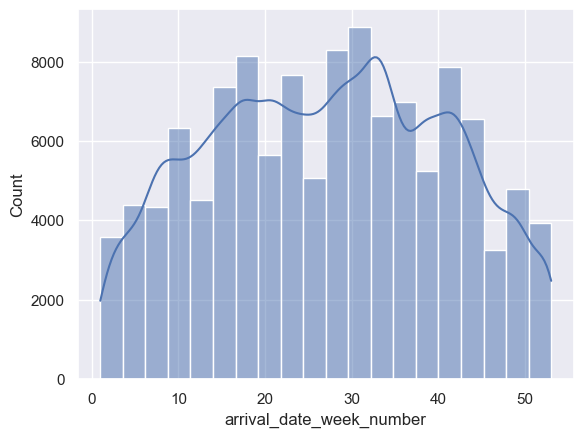

In [41]:
sns.histplot(x='arrival_date_week_number',data=df,bins=20,kde=True)

plt.show()

In [42]:
df['arrival_date_week_number'].describe()

count    119390.000000
mean         27.165173
std          13.605138
min           1.000000
25%          16.000000
50%          28.000000
75%          38.000000
max          53.000000
Name: arrival_date_week_number, dtype: float64

The `arrival_date_week_number` distribution shows that bookings are spread across the entire year, with arrival weeks ranging from 1 to 53. The average arrival week is approximately 27, while the median is 28, indicating that bookings are fairly balanced around the middle of the year.

The relatively close mean and median suggest that the distribution is approximately symmetric, with no major skewness toward the beginning or end of the year. Additionally, the moderate standard deviation (13.61) indicates that hotel arrivals are reasonably distributed across different weeks rather than being concentrated in only a few periods.

The interquartile range shows that 50% of all arrivals occur between weeks 16 and 38, which roughly corresponds to the April–September period. This aligns strongly with earlier monthly trends that indicated peak booking activity during the summer and tourism-heavy seasons.

The absence of extreme irregularities suggests stable booking flow throughout the year, although demand likely intensifies during mid-year vacation periods and declines during off-season weeks.

From a business perspective, weekly arrival patterns are useful for identifying seasonal occupancy cycles, optimizing staffing schedules, forecasting demand, and planning dynamic pricing strategies during peak and low-demand periods.


### arrival_date_day_of_month

<Axes: xlabel='arrival_date_day_of_month', ylabel='Count'>

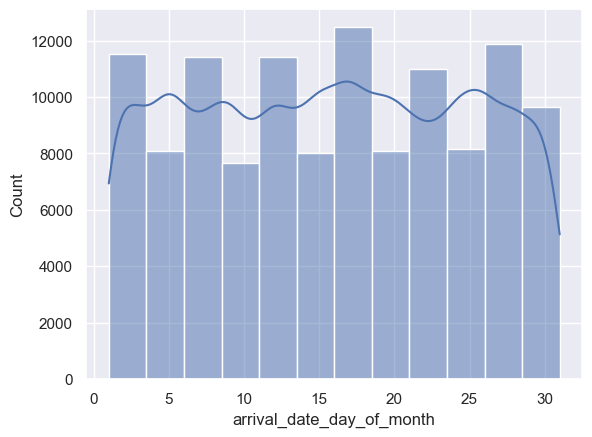

In [45]:
sns.histplot(x='arrival_date_day_of_month',data=df,kde=True,bins=12)

In [46]:
df['arrival_date_day_of_month'].describe()

count    119390.000000
mean         15.798241
std           8.780829
min           1.000000
25%           8.000000
50%          16.000000
75%          23.000000
max          31.000000
Name: arrival_date_day_of_month, dtype: float64

The `arrival_date_day_of_month` distribution indicates that hotel arrivals are fairly evenly spread across the days of the month, with bookings ranging from day 1 to day 31. The mean (15.80) and median (16) are nearly identical, suggesting a highly balanced and symmetric distribution without noticeable skewness.

The quartile distribution shows that 50% of arrivals occur between the 8th and 23rd day of the month, indicating that bookings are concentrated around the middle portion of each month rather than heavily clustered at the beginning or end.

The relatively moderate standard deviation (8.78) further supports the idea that arrivals are consistently distributed throughout the month with no extreme volatility.

This pattern suggests stable customer arrival behavior and indicates that hotel demand is not strongly dependent on specific calendar dates. However, slight fluctuations may still occur around weekends, holidays, salary cycles, or festive periods, which may become clearer when combined with other temporal variables.

From a business perspective, this balanced distribution is beneficial for operational planning, as it reduces the risk of extreme daily occupancy spikes and supports smoother room allocation, staffing, and resource management throughout the month.


### stays_in_weekend_nights

In [49]:
df['stays_in_weekend_nights'].unique()

array([ 0,  1,  2,  4,  3,  6, 13,  8,  5,  7, 12,  9, 16, 18, 19, 10, 14],
      dtype=int64)

<Axes: xlabel='stays_in_weekend_nights', ylabel='count'>

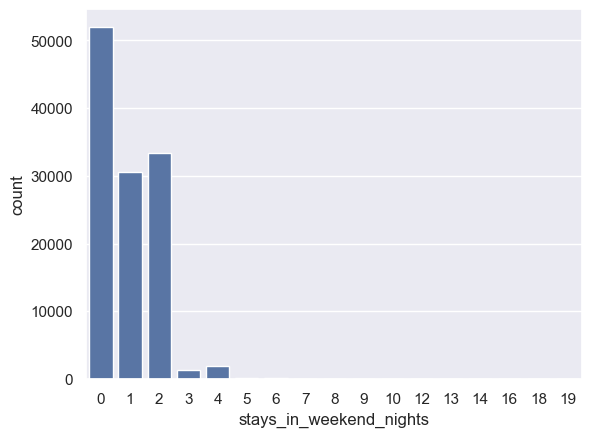

In [50]:
sns.countplot(x='stays_in_weekend_nights',data=df)

In [51]:
df['stays_in_weekend_nights'].value_counts(normalize=True)*100

stays_in_weekend_nights
0     43.553061
2     27.898484
1     25.652065
4      1.553731
3      1.054527
6      0.128151
5      0.066170
8      0.050255
7      0.015914
9      0.009214
10     0.005863
12     0.004188
13     0.002513
16     0.002513
14     0.001675
18     0.000838
19     0.000838
Name: proportion, dtype: float64

The `stays_in_weekend_nights` distribution shows that most customers spend very little time staying over weekends. The highest proportion of bookings (43.55%) includes zero weekend nights, followed by 2-night stays (27.90%) and 1-night stays (25.65%).

This pattern suggests that a large portion of hotel bookings are either weekday-focused or short-duration trips. The dominance of zero weekend stays may indicate strong business travel activity, especially for City Hotels, where guests often check in during weekdays and leave before the weekend.

At the same time, the significant share of 1–2 weekend night stays reflects typical short leisure trips, mini vacations, or weekend getaways. These short stays appear to form the core weekend travel behavior within the dataset.

Longer weekend stays beyond 3 nights are extremely rare, with proportions dropping sharply after 4 nights. This indicates that extended weekend vacations represent only a very small segment of customers.

The distribution is therefore heavily right-skewed, with booking behavior concentrated around short stays and very few long-duration weekend reservations.

From a business perspective, this pattern is useful for understanding occupancy cycles, customer segmentation, and pricing strategies. Weekend stay behavior may also interact strongly with hotel type, cancellation rates, ADR, and customer travel purpose.


### stays_in_week_nights

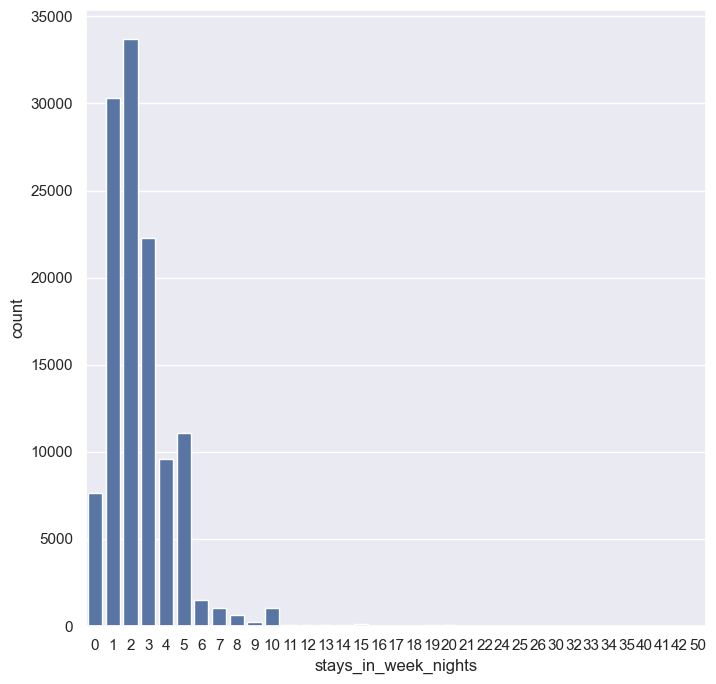

In [54]:
plt.figure(figsize=(8,8))
sns.countplot(x='stays_in_week_nights',data=df)
plt.show()

In [55]:
df['stays_in_week_nights'].value_counts(normalize=True)*100

stays_in_week_nights
2     28.213418
1     25.387386
3     18.643102
5      9.277996
4      8.009884
0      6.403384
6      1.255549
10     0.867744
7      0.861881
8      0.549460
9      0.193484
15     0.071195
11     0.046905
19     0.036854
12     0.035179
20     0.034341
14     0.029316
13     0.022615
16     0.013401
21     0.012564
22     0.005863
25     0.005026
18     0.005026
30     0.004188
17     0.003350
24     0.002513
40     0.001675
33     0.000838
42     0.000838
50     0.000838
32     0.000838
26     0.000838
34     0.000838
35     0.000838
41     0.000838
Name: proportion, dtype: float64

The `stays_in_week_nights` distribution indicates that most guests prefer short weekday stays, with 2-night stays being the most common (28.21%), followed by 1-night (25.39%) and 3-night stays (18.64%).

This pattern strongly suggests that the dataset is dominated by short-duration travel behavior, likely driven by business trips, short vacations, and transit-related stays. The high concentration of 1–3 weekday nights aligns closely with typical urban hotel usage patterns, especially for City Hotels.

Interestingly, weekday stays are generally more common than weekend stays, which further supports the presence of strong business and work-related travel activity within the dataset.

The proportion declines steadily after 5 nights, indicating that long-term weekday stays are relatively uncommon. Extremely long stays extending beyond 10 nights form only a tiny fraction of bookings, showing a heavily right-skewed distribution with very few extended-stay customers.

The presence of some unusually long weekday stays (20–50 nights) may represent corporate accommodations, temporary relocations, group bookings, or data outliers that may require further investigation.

From a business perspective, these patterns are important for occupancy planning, pricing strategy, customer segmentation, and revenue forecasting, as stay duration often influences ADR, cancellation behavior, and hotel resource utilization.


### adults

<Axes: xlabel='adults', ylabel='count'>

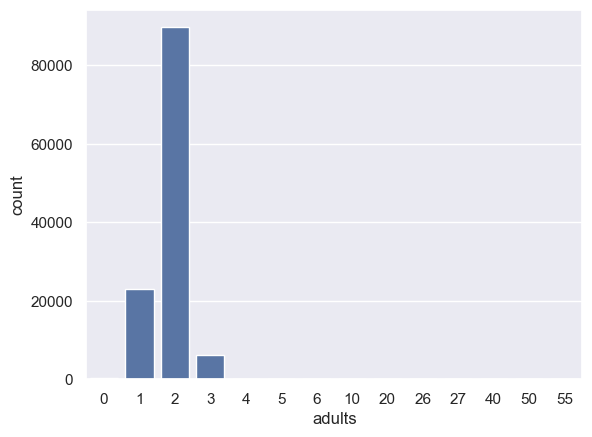

In [58]:
sns.countplot(x='adults',data=df)

In [59]:
df['adults'].value_counts(normalize=True)*100

adults
2     75.115169
1     19.287210
3      5.194740
0      0.337549
4      0.051931
26     0.004188
27     0.001675
20     0.001675
5      0.001675
40     0.000838
50     0.000838
55     0.000838
6      0.000838
10     0.000838
Name: proportion, dtype: float64

Adults Feature Analysis — Summary

The `adults` variable shows a highly concentrated booking pattern dominated by **2-adult reservations (~75.1%)**, indicating that couples and dual-traveler bookings form the core customer segment. This suggests hotel operations and room inventory are primarily optimized for double occupancy.

Single-adult bookings account for nearly **19.3%** of reservations, highlighting a strong presence of solo travelers and business-related stays. Bookings with **3 adults (~5.2%)** form a smaller secondary segment, while reservations with more than 4 adults are extremely rare.

The distribution is strongly right-skewed, with unrealistic values such as 20, 26, 40, and 55 adults likely representing data-entry anomalies or rare bulk-booking cases. These outliers may require treatment during preprocessing.

Key Patterns & Insights

* Strong dominance of couple-based travel behavior.
* Solo travelers form a significant secondary segment.
* Large-group bookings are uncommon.
* Clear long-tail distribution with extreme outliers.

Modeling Implications

The `adults` feature may become more informative when combined with:

* `children`
* `babies`
* `ADR`
* `room_type`
* `market_segment`

Feature engineering opportunities include:

* `total_guests`
* traveler-type categories (`solo`, `couple`, `family`, `group`)


In [61]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')

### children

<Axes: xlabel='children', ylabel='count'>

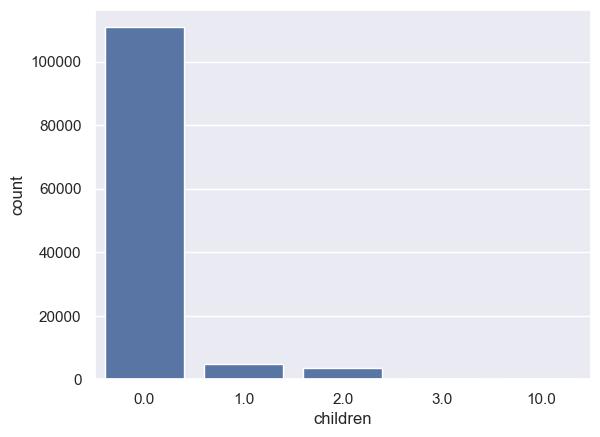

In [63]:
sns.countplot(x='children',data=df)

In [64]:
df['children'].value_counts(normalize=True)*100

children
0.0     92.804851
1.0      4.071667
2.0      3.058985
3.0      0.063659
10.0     0.000838
Name: proportion, dtype: float64

Children Feature Analysis — Summary

The `children` variable shows that the vast majority of hotel bookings (**~92.8%**) do not include children, indicating that most reservations are made by couples, solo travelers, or adult-only groups. This reinforces the earlier occupancy patterns observed in the `adults` feature.

Bookings with **1 child (~4.1%)** and **2 children (~3.1%)** form a small but meaningful segment, suggesting the presence of family-oriented travel behavior within the dataset. Reservations involving 3 children are extremely rare, while the value of 10 children appears operationally unrealistic and likely represents a data-entry anomaly or exceptional bulk-booking case.

The distribution is therefore highly right-skewed, with family travel present but clearly secondary to adult-only bookings.

Key Patterns & Insights

* Adult-only bookings overwhelmingly dominate the dataset.
* Family travel exists but represents a relatively small share of total reservations.
* Most family bookings involve only 1–2 children.
* Extreme child-count values indicate potential outliers or recording issues.

Modeling Implications

The `children` feature may provide stronger predictive value when combined with:

* `adults`
* `babies`
* `ADR`
* `hotel`
* `meal`
* `market_segment`

Potential feature engineering opportunities include:

* `total_guests`
* `is_family`
* occupancy-based traveler categories (`couple`, `family`, `group`)


### babies

<Axes: xlabel='babies', ylabel='count'>

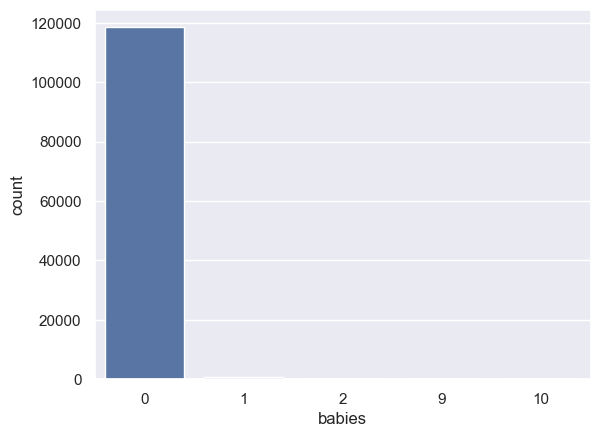

In [67]:
sns.countplot(x='babies',data=df)

In [68]:
df['babies'].value_counts(normalize=True)*100

babies
0     99.231929
1      0.753832
2      0.012564
10     0.000838
9      0.000838
Name: proportion, dtype: float64

Babies Feature Analysis — Summary

The `babies` variable indicates that hotel bookings involving infants are extremely uncommon. Approximately **99.2%** of reservations contain no babies, showing that the dataset is overwhelmingly dominated by adult-only and non-infant family travel.

Bookings with **1 baby (~0.75%)** represent a very small niche segment, while reservations involving 2 or more babies are nearly negligible. Extreme values such as 9 and 10 babies are operationally unrealistic and likely indicate data-entry anomalies or recording errors.

The distribution is therefore highly imbalanced and strongly right-skewed, with infant-inclusive travel contributing minimally to overall booking behavior.

Key Patterns & Insights

* Infant-related bookings are exceptionally rare.
* Family travel in this dataset is primarily driven by children rather than babies.
* Extreme baby counts indicate probable outliers or data-quality issues.
* Hotels in this dataset appear to cater predominantly to adult travelers and couples.

Modeling Implications

The standalone predictive power of `babies` is likely limited due to extreme imbalance. However, it may become useful when combined with:

* `children`
* `adults`
* `meal`
* `hotel`
* `reserved_room_type`

Potential feature engineering opportunities include:

* `total_guests`
* `has_baby` flag
* family-traveler segmentation (`family_with_infant`)


In [70]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')

### meal

In [72]:
df['meal'].unique()

array(['BB', 'FB', 'HB', 'SC', 'Undefined'], dtype=object)

<Axes: xlabel='meal', ylabel='count'>

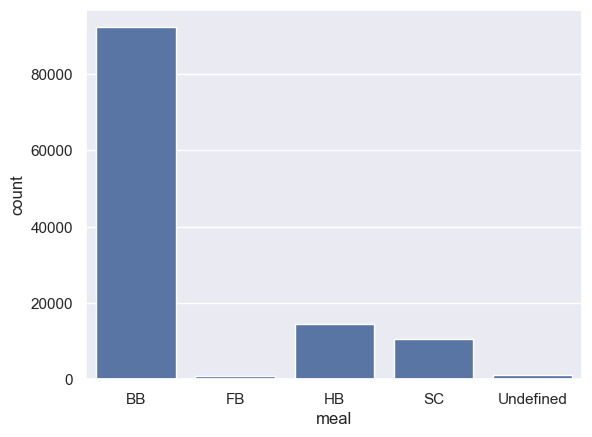

In [73]:
sns.countplot(x='meal',data=df)

In [74]:
df['meal'].value_counts(normalize=True)*100

meal
BB           77.318033
HB           12.114080
SC            8.920345
Undefined     0.979144
FB            0.668398
Name: proportion, dtype: float64

Meal Feature Analysis — Summary

The `meal` variable shows that **Bed & Breakfast (BB)** is the dominant meal plan, accounting for approximately **77.3%** of all bookings. This suggests that most guests prefer flexible dining arrangements rather than fully bundled meal packages, which is common in urban tourism and short-stay travel behavior.

**Half Board (HB) (~12.1%)** and **Self Catering (SC) (~8.9%)** form meaningful secondary segments. HB likely reflects leisure or resort-oriented travelers seeking partial meal inclusion, while SC indicates guests preferring independence and external dining options.

**Full Board (FB)** bookings are extremely limited (**~0.7%**), suggesting low demand for fully inclusive meal packages within this dataset. The presence of an `Undefined` category (~1%) may indicate missing, inconsistent, or improperly recorded booking information.

Key Patterns & Insights

* Strong dominance of flexible meal preferences (`BB`).
* Limited demand for fully inclusive meal plans (`FB`).
* Self-catering behavior suggests independent or longer-stay travelers.
* Meal-plan choices may reflect differences between city and resort hotel behavior.
* Presence of `Undefined` values indicates minor data-quality inconsistencies.

Modeling Implications

The `meal` feature may provide useful behavioral signals when analyzed alongside:

* `hotel`
* `ADR`
* `market_segment`
* `stays_in_week_nights`
* `is_canceled`

Potential feature engineering opportunities include:

* grouping meal plans into flexible vs inclusive categories,
* identifying resort-style vs business-style booking behavior,
* and analyzing meal preference impact on cancellation patterns and pricing.


### country

In [77]:
df['country'].nunique()

177

In [78]:
df['country'].value_counts(normalize=True).head(10)

country
PRT    0.408656
GBR    0.102008
FRA    0.087593
ESP    0.072059
DEU    0.061286
ITA    0.031673
IRL    0.028385
BEL    0.019697
BRA    0.018704
NLD    0.017695
Name: proportion, dtype: float64

C:\Users\kavit\AppData\Local\Temp\ipykernel_1272\2293932162.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


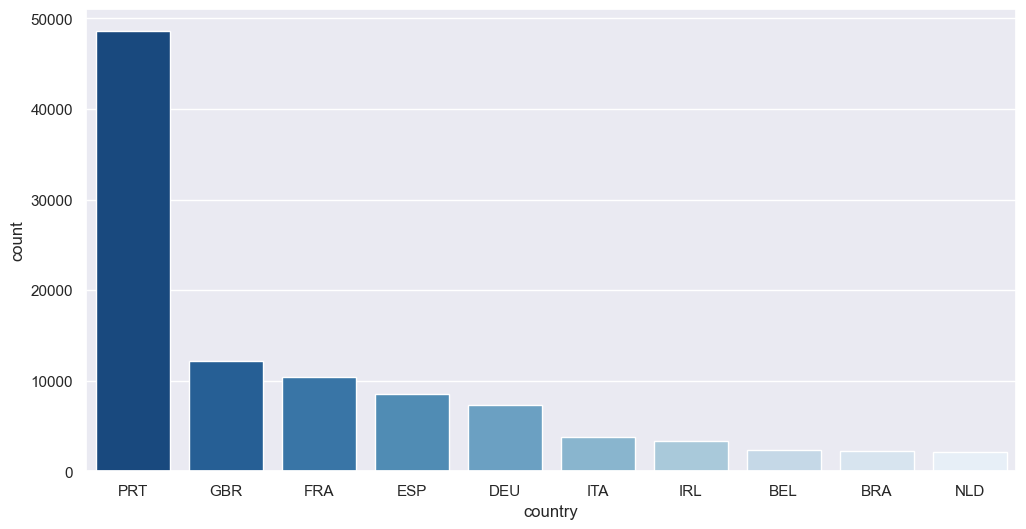

In [79]:
plt.figure(figsize=(12, 6))

# 2. Extract the top 10 countries dynamically to maintain a sorted order
top_10_countries = df['country'].value_counts().head(10).index

# 3. Generate the countplot restricted to our top 10 cohort
ax = sns.countplot(
    x='country', 
    data=df[df['country'].isin(top_10_countries)], 
    order=top_10_countries,
    palette='Blues_r'  # Gradient palette emphasizing higher volume
)

Country Feature Analysis — Top Visitor Origins

The `country` variable reveals a strong concentration of bookings from European travelers, with **Portugal (PRT)** contributing the largest share of reservations at approximately **40.9%**. This indicates a significant domestic tourism presence and suggests that local travelers form the core customer base of the hotels.

The **United Kingdom (GBR)**, **France (FRA)**, **Spain (ESP)**, and **Germany (DEU)** collectively account for a substantial portion of international bookings, highlighting Western Europe as the primary international tourism market. Countries such as **Italy (ITA)**, **Ireland (IRL)**, **Belgium (BEL)**, **Brazil (BRA)**, and **Netherlands (NLD)** contribute smaller but meaningful shares.

Key Patterns & Insights

* Strong dominance of domestic Portuguese travelers.
* International demand is heavily concentrated in European countries.
* Western Europe represents the primary foreign tourism market.
* Brazil’s presence suggests long-haul tourism connections beyond Europe.
* Visitor distribution indicates the hotels primarily cater to regional and nearby international travelers.

Business Insights

These patterns suggest that:

* marketing strategies may be strongly localized toward Portuguese customers,
* seasonal tourism demand is likely influenced by European holiday calendars,
* and multilingual hospitality services may be important for operational efficiency.

Modeling Implications

The `country` feature may provide strong behavioral signals when combined with:

* `ADR`
* `lead_time`
* `meal`
* `market_segment`
* `is_canceled`

Potential feature engineering opportunities include:

* domestic vs international traveler classification,
* regional grouping (Western Europe, South America, etc.),
* and country-level cancellation or spending behavior analysis.


### market_segment

In [82]:
df['market_segment'].unique()

array(['Direct', 'Corporate', 'Online TA', 'Offline TA/TO',
       'Complementary', 'Groups', 'Undefined', 'Aviation'], dtype=object)

<Axes: xlabel='count', ylabel='market_segment'>

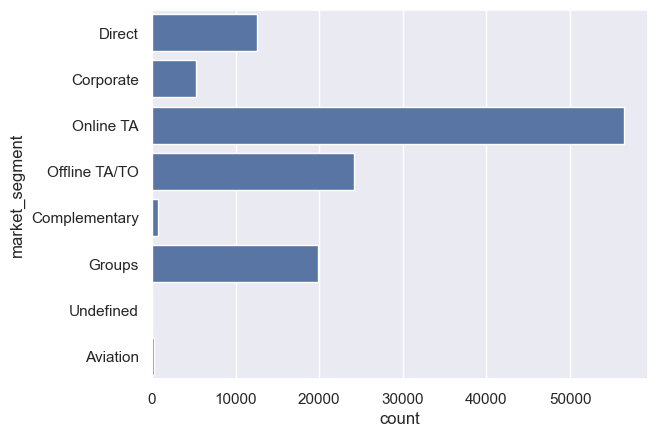

In [83]:
sns.countplot(y='market_segment',data=df)

In [84]:
df['market_segment'].value_counts(normalize=True)*100

market_segment
Online TA        47.304632
Offline TA/TO    20.285619
Groups           16.593517
Direct           10.558673
Corporate         4.435045
Complementary     0.622330
Aviation          0.198509
Undefined         0.001675
Name: proportion, dtype: float64

Market Segment Analysis — Summary

The `market_segment` variable shows that **Online Travel Agencies (Online TA)** dominate hotel bookings, contributing approximately **47.3%** of all reservations. This highlights the strong influence of digital booking platforms and indicates that online intermediaries are the primary customer acquisition channel for the hotels.

**Offline TA/TO (~20.3%)** and **Groups (~16.6%)** also represent significant booking sources, suggesting continued dependence on traditional travel agencies, tour operators, and organized group travel. Direct bookings account for only **~10.6%**, indicating comparatively lower direct customer engagement.

The **Corporate (~4.4%)** segment forms a smaller but stable business-travel category, while `Complementary` and `Aviation` bookings contribute minimally. The `Undefined` category is negligible and likely represents minor data-entry inconsistencies.

Key Patterns & Insights

* Strong dominance of online booking platforms.
* Significant reliance on third-party intermediaries.
* Group travel forms a major customer segment.
* Direct bookings remain relatively limited.
* Corporate travel exists but is not the primary demand driver.

Business Insights

These patterns suggest that:

* hotel revenue is heavily dependent on OTA ecosystems,
* commission-based booking channels likely play a major operational role,
* and increasing direct bookings could improve profitability and customer retention.

The presence of large group and offline bookings may also indicate strong tourism package partnerships and seasonal travel flows.

Modeling Implications

The `market_segment` feature is likely to be highly predictive when analyzed alongside:

* `is_canceled`
* `ADR`
* `lead_time`
* `hotel`
* `deposit_type`

Potential feature engineering opportunities include:

* online vs offline booking classification,
* direct vs intermediary segmentation,
* and group-travel behavioral profiling.


### distribution_channel

In [87]:
df['distribution_channel'].unique()

array(['Direct', 'Corporate', 'TA/TO', 'Undefined', 'GDS'], dtype=object)

<Axes: xlabel='distribution_channel', ylabel='count'>

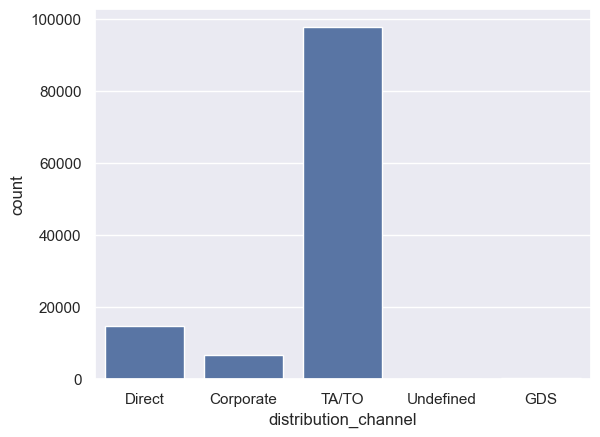

In [88]:
sns.countplot(x='distribution_channel',data=df)

In [89]:
df['distribution_channel'].value_counts(normalize=True)*100

distribution_channel
TA/TO        81.975040
Direct       12.266521
Corporate     5.592596
GDS           0.161655
Undefined     0.004188
Name: proportion, dtype: float64

Distribution Channel Analysis — Summary

The `distribution_channel` variable shows that **Travel Agents and Tour Operators (TA/TO)** overwhelmingly dominate hotel reservations, accounting for approximately **82%** of all bookings. This indicates a strong dependence on intermediary-based distribution networks for customer acquisition and revenue generation.

**Direct bookings (~12.3%)** form a much smaller segment, suggesting that relatively few customers book directly through hotel-owned channels. The **Corporate (~5.6%)** channel represents a modest but stable source of business-related travel demand.

The **Global Distribution System (GDS)** channel contributes negligibly, indicating limited reliance on airline-linked or enterprise reservation systems. The `Undefined` category is nearly nonexistent and likely reflects minor recording inconsistencies.

Key Patterns & Insights

* Extremely high dependence on TA/TO distribution networks.
* Direct booking share remains relatively low.
* Corporate travel contributes a small but consistent segment.
* GDS-based bookings are minimal.
* Distribution structure is heavily intermediary-driven.

Business Insights

These patterns suggest that:

* hotels rely significantly on third-party distribution ecosystems,
* commission-related operational costs may be substantial,
* and increasing direct booking penetration could improve profitability and customer loyalty.

The strong TA/TO dominance also indicates that tourism package partnerships and organized travel networks play a major role in booking behavior.

Modeling Implications

The `distribution_channel` feature may provide strong predictive value when combined with:

* `market_segment`
* `ADR`
* `lead_time`
* `deposit_type`
* `is_canceled`

Potential feature engineering opportunities include:

* intermediary vs direct booking classification,
* corporate vs leisure segmentation,
* and channel-based cancellation risk analysis.


In [91]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')

### is_repeated_guest

In [93]:
df['is_repeated_guest'].unique()

array([0, 1], dtype=int64)

<Axes: xlabel='is_repeated_guest', ylabel='count'>

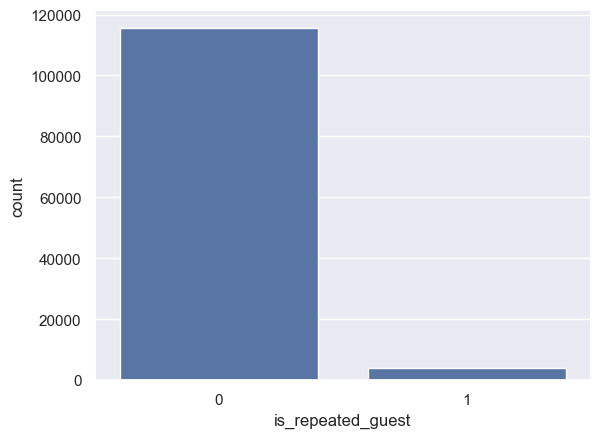

In [94]:
sns.countplot(x='is_repeated_guest',data=df)

In [95]:
df['is_repeated_guest'].value_counts(normalize=True)*100

is_repeated_guest
0    96.808778
1     3.191222
Name: proportion, dtype: float64

Repeated Guest Analysis — Summary

The `is_repeated_guest` variable shows that the vast majority of hotel reservations (**~96.8%**) come from first-time guests, while only **~3.2%** of bookings are made by returning customers. This indicates that repeat customer retention is relatively low within the dataset.

The distribution suggests that hotel demand is driven primarily by transient travelers rather than long-term customer loyalty. This pattern is common in tourism-heavy destinations where bookings are heavily influenced by seasonal travel, online travel agencies, and one-time leisure visits.

Key Patterns & Insights

* First-time guests overwhelmingly dominate hotel bookings.
* Repeat customer share is extremely small.
* Customer behavior appears more tourism-driven than loyalty-driven.
* Heavy dependence on OTA and intermediary channels may contribute to lower repeat engagement.

Business Insights

These patterns suggest that:

* customer acquisition likely plays a larger role than customer retention,
* loyalty programs and personalized marketing may be underutilized,
* and increasing repeat guest conversion could improve long-term profitability and reduce acquisition costs.

Modeling Implications

The `is_repeated_guest` feature may provide strong predictive value when analyzed with:

* `is_canceled`
* `lead_time`
* `ADR`
* `distribution_channel`
* `market_segment`

Potential feature engineering opportunities include:

* loyalty-based customer segmentation,
* repeat vs first-time cancellation analysis,
* and customer lifetime value estimation.


### previous_cancellations

<Axes: xlabel='previous_cancellations', ylabel='count'>

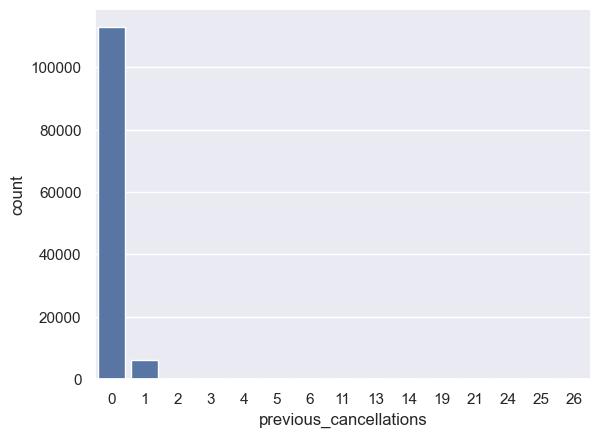

In [98]:
sns.countplot(x='previous_cancellations',data=df)

In [99]:
df['previous_cancellations'].unique()

array([ 0,  1,  2,  3, 26, 25, 14,  4, 24, 19,  5, 21,  6, 13, 11],
      dtype=int64)

In [100]:
df['previous_cancellations'].value_counts(normalize=True)*100

previous_cancellations
0     94.569059
1      5.068264
2      0.097161
3      0.054443
24     0.040204
11     0.029316
4      0.025965
26     0.021777
25     0.020940
6      0.018427
19     0.015914
5      0.015914
14     0.011726
13     0.010051
21     0.000838
Name: proportion, dtype: float64

Previous Cancellations Analysis — Summary

The `previous_cancellations` variable shows that the overwhelming majority of guests (**~94.6%**) have no prior cancellation history, indicating that most customers do not exhibit repeated cancellation behavior.

A smaller segment of guests (**~5.1%**) has exactly one previous cancellation, while higher cancellation counts occur very rarely. The distribution is therefore heavily right-skewed, with a long tail of extreme values such as 11, 19, 24, 25, and 26 previous cancellations.

These unusually high cancellation counts may represent:

* highly unreliable booking behavior,
* bulk/corporate reservation patterns,
* or potential data irregularities.

Key Patterns & Insights

* Most guests have clean booking histories with no prior cancellations.
* A small subset of customers shows recurring cancellation behavior.
* The distribution contains a long tail of extreme repeat cancellers.
* Cancellation behavior appears highly concentrated among a very small group of users.

Business Insights

These patterns suggest that:

* chronic cancellation behavior is limited but potentially impactful,
* repeat cancellers may contribute disproportionately to operational uncertainty,
* and hotels may benefit from stricter booking policies or deposit requirements for high-risk customers.

Modeling Implications

The `previous_cancellations` feature is likely to be highly predictive for:

* `is_canceled`
* booking reliability
* customer risk profiling

It may become even more informative when combined with:

* `deposit_type`
* `lead_time`
* `market_segment`
* `distribution_channel`

Potential feature engineering opportunities include:

* cancellation-risk categories,
* frequent-canceller flags,
* and customer reliability scoring.


### previous_bookings_not_canceled

In [103]:
df['previous_bookings_not_canceled'].unique()

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 20, 21, 22, 23, 24, 25, 27, 28, 29, 30, 19, 26, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
       68, 69, 70, 71, 72], dtype=int64)

In [104]:
df['previous_bookings_not_canceled'].value_counts(normalize=True)*100

previous_bookings_not_canceled
0     96.967920
1      1.291565
2      0.485803
3      0.278918
4      0.191808
        ...    
47     0.000838
49     0.000838
50     0.000838
51     0.000838
72     0.000838
Name: proportion, Length: 73, dtype: float64

Previous Bookings Not Canceled Analysis — Summary

The `previous_bookings_not_canceled` variable shows that approximately **97%** of guests have no prior successful booking history, indicating that most reservations are made by first-time or infrequent customers. Only a small portion of guests have previously completed bookings without cancellation.

The distribution is heavily right-skewed, with frequencies declining rapidly as the number of successful past bookings increases. However, a long tail of high values extending up to 72 previous successful bookings suggests the existence of a small but highly loyal customer segment.

Key Patterns & Insights

* First-time or low-frequency guests dominate the dataset.
* A small subset of customers demonstrates strong repeat-booking behavior.
* Distribution shows a long-tail loyalty pattern.
* High-value repeat customers exist but represent a very small share of total bookings.

Business Insights

These patterns suggest that:

* customer retention is relatively limited overall,
* but a niche segment of highly loyal guests contributes recurring business,
* and identifying and retaining these customers could provide long-term revenue stability.

The contrast between low repeat-booking frequency and dominant OTA usage also indicates that intermediary-driven bookings may reduce long-term customer loyalty.

Modeling Implications

The `previous_bookings_not_canceled` feature may provide valuable signals for:

* customer loyalty,
* cancellation prediction,
* and guest reliability analysis.

It may become especially informative when combined with:

* `is_repeated_guest`
* `previous_cancellations`
* `ADR`
* `distribution_channel`

Potential feature engineering opportunities include:

* customer loyalty scoring,
* repeat-booking frequency categories,
* and reliability-based guest segmentation.


In [106]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')

### reserved_room_type

In [108]:
df['reserved_room_type'].unique()

array(['C', 'A', 'D', 'E', 'G', 'F', 'H', 'L', 'P', 'B'], dtype=object)

<Axes: xlabel='reserved_room_type', ylabel='count'>

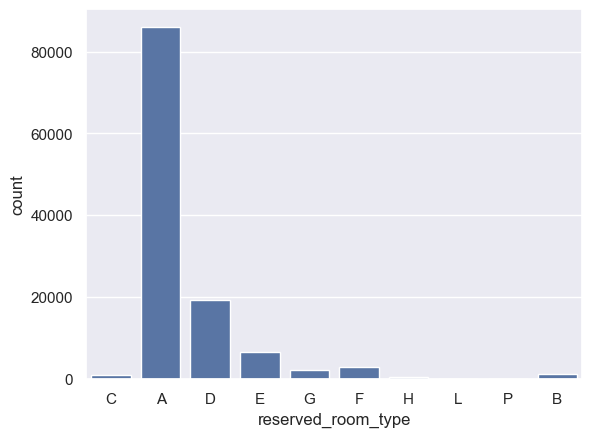

In [109]:
sns.countplot(x='reserved_room_type',data=df)

In [110]:
df['reserved_room_type'].value_counts(normalize=True)*100


reserved_room_type
A    72.027808
D    16.082586
E     5.473658
F     2.426501
G     1.753916
B     0.936427
C     0.780635
H     0.503392
P     0.010051
L     0.005026
Name: proportion, dtype: float64

Reserved Room Type Analysis — Summary

The `reserved_room_type` variable shows a highly concentrated booking pattern, with **Room Type A** dominating reservations at approximately **72%** of all bookings. This indicates that standard room categories form the core demand segment and likely represent the hotel’s primary inventory offering.

**Room Type D (~16.1%)** emerges as the second most preferred category, while room types **E, F, and G** contribute smaller but meaningful shares. Premium or specialized room categories such as **H, L, and P** are booked very rarely, suggesting limited demand for luxury or niche accommodation options.

The distribution is strongly imbalanced, with booking frequencies declining sharply beyond the most common room categories.

Key Patterns & Insights

* Extremely high demand concentration in Room Type A.
* Mid-tier room categories (`D`, `E`, `F`) form secondary demand segments.
* Premium/specialized room types show very limited utilization.
* Room demand appears heavily skewed toward standard accommodation options.

Business Insights

These patterns suggest that:

* hotel revenue is likely driven primarily by standard room inventory,
* occupancy optimization strategies should focus heavily on high-demand room categories,
* and premium room types may serve niche or seasonal demand segments rather than mass-market travelers.

The dominance of standard rooms also aligns with earlier findings showing strong couple-based and short-stay booking behavior.

Modeling Implications

The `reserved_room_type` feature may provide important behavioral and pricing signals when analyzed alongside:

* `ADR`
* `hotel`
* `market_segment`
* `meal`
* `is_canceled`

Potential feature engineering opportunities include:

* standard vs premium room classification,
* room-demand segmentation,
* and room-upgrade/downgrade analysis using assigned room types.


### assigned_room_type

<Axes: xlabel='assigned_room_type', ylabel='count'>

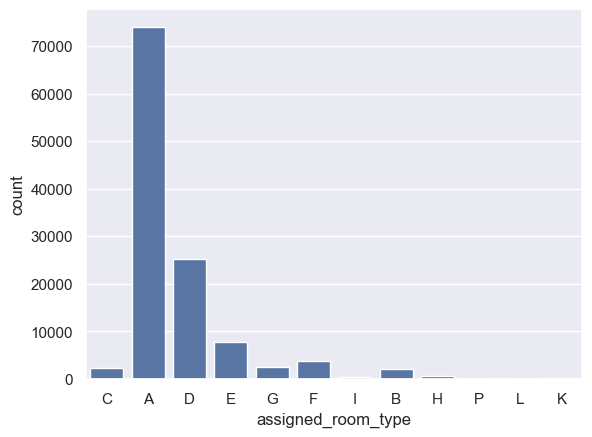

In [113]:
sns.countplot(x='assigned_room_type',data=df)

In [114]:
df['assigned_room_type'].value_counts(normalize=True)*100

assigned_room_type
A    62.026133
D    21.209482
E     6.538236
F     3.141804
G     2.138370
C     1.989279
B     1.811710
H     0.596365
I     0.304046
K     0.233688
P     0.010051
L     0.000838
Name: proportion, dtype: float64

Assigned Room Type Analysis — Summary

The `assigned_room_type` variable shows that **Room Type A** remains the most frequently allocated category, accounting for approximately **62%** of all assignments. However, its share is notably lower than its reserved proportion (~72%), indicating that room reallocations and upgrades occur relatively frequently during hotel operations.

Compared to reserved room patterns, room types **D, E, F, and G** show higher assignment proportions, suggesting that guests are often shifted into alternative or upgraded room categories based on availability and occupancy management.

Additional assigned room categories such as **I** and **K**, which were absent or negligible in reservations, indicate operational flexibility in room allocation. Premium room types remain rare overall, reflecting limited demand for luxury accommodations.

Key Patterns & Insights

* Room Type A dominates both reservations and assignments.
* Assigned room distribution is more diversified than reserved room distribution.
* Evidence of room upgrades or operational reallocations exists.
* Mid-tier room categories receive proportionally more assignments than reservations.
* Premium room categories remain minimally utilized.

Business Insights

These patterns suggest that:

* hotels actively optimize occupancy through dynamic room allocation,
* upgrades may be used to manage overbooking or improve customer satisfaction,
* and inventory management plays a significant operational role in balancing room demand.

The gap between reserved and assigned room types may also reflect seasonal occupancy pressure and room availability constraints.

Modeling Implications

The `assigned_room_type` feature may provide valuable operational signals when combined with:

* `reserved_room_type`
* `ADR`
* `hotel`
* `is_canceled`

Potential feature engineering opportunities include:

* room upgrade/downgrade flags,
* room mismatch analysis,
* and operational allocation efficiency metrics.


In [116]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')

### booking_changes

In [118]:
df['booking_changes'].unique()

array([ 3,  4,  0,  1,  2,  5, 17,  6,  8,  7, 10, 16,  9, 13, 12, 20, 14,
       15, 11, 21, 18], dtype=int64)

<Axes: xlabel='booking_changes', ylabel='count'>

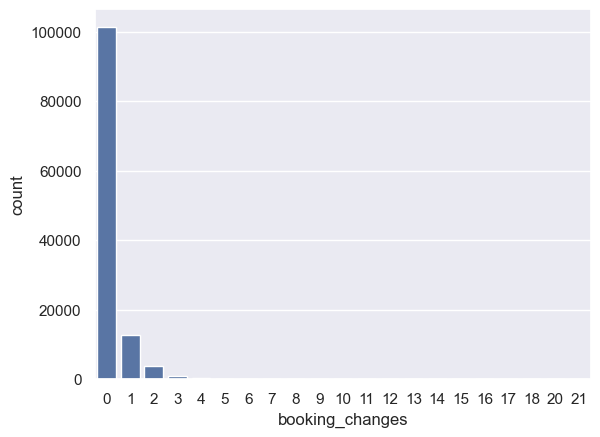

In [119]:
sns.countplot(x='booking_changes',data=df)

In [120]:
df['booking_changes'].value_counts(normalize=True)*100

booking_changes
0     84.859703
1     10.638244
2      3.187034
3      0.776447
4      0.314934
5      0.098836
6      0.052768
7      0.025965
8      0.014239
9      0.006701
10     0.005026
13     0.004188
14     0.004188
15     0.002513
16     0.001675
17     0.001675
12     0.001675
11     0.001675
20     0.000838
21     0.000838
18     0.000838
Name: proportion, dtype: float64

Booking Changes Analysis — Summary

The `booking_changes` variable shows that the majority of reservations (**~84.9%**) undergo no modifications after the initial booking, indicating that most customers finalize their travel plans at the time of reservation.

Approximately **10.6%** of bookings experience one change, while smaller proportions undergo multiple modifications. The frequency declines rapidly as the number of booking changes increases, creating a strongly right-skewed distribution with a long tail of highly modified reservations.

Extreme values involving 10 or more booking changes are exceptionally rare and may represent:

* complex travel arrangements,
* group or corporate bookings,
* or operational adjustment cases.

Key Patterns & Insights

* Most bookings remain unchanged after confirmation.
* A moderate subset of guests modifies reservations at least once.
* Frequent booking modifications are uncommon.
* Distribution shows strong right skew with rare extreme cases.

Business Insights

These patterns suggest that:

* customer travel plans are generally stable,
* operational workload from booking adjustments is concentrated among a small subset of reservations,
* and highly modified bookings may indicate uncertain travelers or complex itineraries.

Frequent booking changes may also correlate with:

* longer lead times,
* higher cancellation risk,
* or group travel behavior.

Modeling Implications

The `booking_changes` feature may provide useful behavioral signals when analyzed with:

* `lead_time`
* `market_segment`
* `is_canceled`
* `distribution_channel`

Potential feature engineering opportunities include:

* booking flexibility categories,
* high-modification customer flags,
* and booking stability scoring.


### deposit_type

In [123]:
df['deposit_type'].unique()

array(['No Deposit', 'Refundable', 'Non Refund'], dtype=object)

<Axes: xlabel='deposit_type', ylabel='count'>

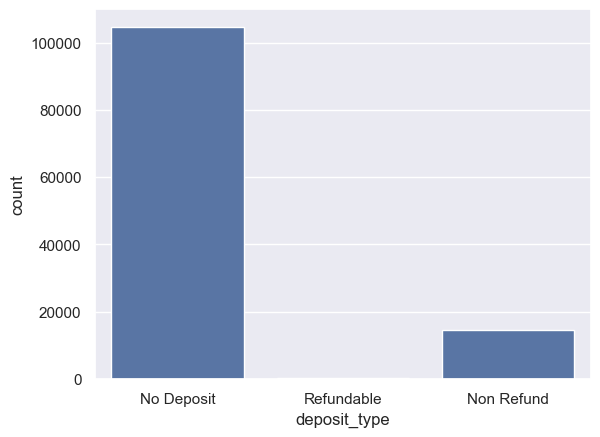

In [124]:
sns.countplot(x='deposit_type',data=df)

In [125]:
df['deposit_type'].value_counts(normalize=True)*100

deposit_type
No Deposit    87.646369
Non Refund    12.217941
Refundable     0.135690
Name: proportion, dtype: float64

Deposit Type Analysis — Summary

The `deposit_type` variable shows that the overwhelming majority of bookings (**~87.6%**) are made without any deposit requirement, indicating that hotels primarily operate with flexible booking policies.

Approximately **12.2%** of reservations fall under the `Non Refund` category, representing a smaller but significant segment of stricter booking arrangements. Fully `Refundable` deposits are extremely rare (**~0.1%**), suggesting limited use of formal refundable deposit structures within the dataset.

The distribution indicates a strong preference for booking flexibility, likely influenced by OTA-driven reservation behavior and competitive hospitality market dynamics.

Key Patterns & Insights

* Most bookings are made without upfront financial commitment.
* Non-refundable reservations form a meaningful secondary segment.
* Refundable deposit structures are nearly nonexistent.
* Booking behavior appears heavily flexibility-oriented.

Business Insights

These patterns suggest that:

* hotels prioritize lower booking friction to maximize occupancy,
* flexible reservation policies may contribute to higher cancellation exposure,
* and non-refundable bookings likely serve as a risk-control mechanism for selected customers or booking channels.

The relationship between `deposit_type` and cancellation behavior is likely to be particularly important operationally.

Modeling Implications

The `deposit_type` feature is likely to be highly predictive for:

* `is_canceled`
* customer reliability
* booking commitment behavior

It may become even more informative when combined with:

* `lead_time`
* `market_segment`
* `distribution_channel`
* `previous_cancellations`

Potential feature engineering opportunities include:

* flexible vs strict booking classification,
* cancellation-risk profiling,
* and booking commitment scoring.


### agent

In [128]:
df['agent'].unique()

array([ nan, 304., 240., 303.,  15., 241.,   8., 250., 115.,   5., 175.,
       134., 156., 243., 242.,   3., 105.,  40., 147., 306., 184.,  96.,
         2., 127.,  95., 146.,   9., 177.,   6., 143., 244., 149., 167.,
       300., 171., 305.,  67., 196., 152., 142., 261., 104.,  36.,  26.,
        29., 258., 110.,  71., 181.,  88., 251., 275.,  69., 248., 208.,
       256., 314., 126., 281., 273., 253., 185., 330., 334., 328., 326.,
       321., 324., 313.,  38., 155.,  68., 335., 308., 332.,  94., 348.,
       310., 339., 375.,  66., 327., 387., 298.,  91., 245., 385., 257.,
       393., 168., 405., 249., 315.,  75., 128., 307.,  11., 436.,   1.,
       201., 183., 223., 368., 336., 291., 464., 411., 481.,  10., 154.,
       468., 410., 390., 440., 495., 492., 493., 434.,  57., 531., 420.,
       483., 526., 472., 429.,  16., 446.,  34.,  78., 139., 252., 270.,
        47., 114., 301., 193., 182., 135., 350., 195., 352., 355., 159.,
       363., 384., 360., 331., 367.,  64., 406., 16

<Axes: xlabel='agent', ylabel='Count'>

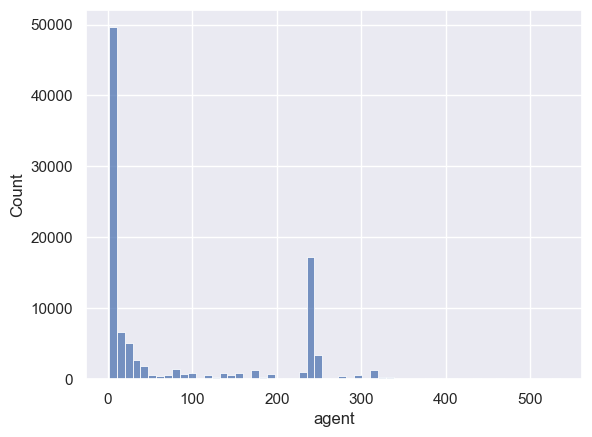

In [129]:
sns.histplot(x='agent',data=df)

In [130]:
df['agent'].value_counts(normalize=True)*100

agent
9.0      31.015041
240.0    13.509947
1.0       6.978166
14.0      3.532266
7.0       3.434255
           ...    
289.0     0.000970
432.0     0.000970
265.0     0.000970
93.0      0.000970
304.0     0.000970
Name: proportion, Length: 333, dtype: float64

Agent Feature Analysis — Summary

The `agent` variable represents the travel agents or intermediaries responsible for hotel bookings. The distribution shows that booking activity is highly concentrated among a small number of agents, with **Agent 9 (~31%)** and **Agent 240 (~13.5%)** dominating a substantial share of total reservations.

Beyond the top few agents, booking frequencies decline rapidly across a very large number of low-frequency agents, producing a highly right-skewed and high-cardinality distribution. This indicates that while a few intermediaries contribute heavily to hotel demand, most agents generate only occasional bookings.

Key Patterns & Insights

* Hotel bookings are heavily concentrated among a small number of agents.
* A long-tail distribution exists across hundreds of low-frequency agents.
* Strong intermediary dependence aligns with earlier OTA and TA/TO findings.
* Certain agents likely represent major travel platforms or high-volume partners.

Business Insights

These patterns suggest that:

* hotel revenue may depend significantly on a limited set of high-volume intermediaries,
* operational and financial risk could increase if major agent partnerships weaken,
* and top-performing agents likely play a critical role in occupancy generation.

The concentration pattern also indicates opportunities for:

* partner segmentation,
* commission optimization,
* and targeted business relationship management.

Modeling Implications

The `agent` feature may contain strong behavioral and cancellation signals, but its extremely high cardinality may create modeling challenges.

Potential preprocessing strategies include:

* frequency encoding,
* target encoding,
* grouping rare agents into an `Other` category,
* or focusing only on top-performing agents.

The feature may become particularly informative when analyzed alongside:

* `market_segment`
* `distribution_channel`
* `ADR`
* `is_canceled`
* `lead_time`


In [132]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')

### company

In [134]:
df['company'].unique()

array([ nan, 110., 113., 270., 178., 240., 154., 144., 307., 268.,  59.,
       204., 312., 318.,  94., 174., 274., 195., 223., 317., 281., 118.,
        53., 286.,  12.,  47., 324., 342., 373., 371., 383.,  86.,  82.,
       218.,  88.,  31., 397., 392., 405., 331., 367.,  20.,  83., 416.,
        51., 395., 102.,  34.,  84., 360., 394., 457., 382., 461., 478.,
       386., 112., 486., 421.,   9., 308., 135., 224., 504., 269., 356.,
       498., 390., 513., 203., 263., 477., 521., 169., 515., 445., 337.,
       251., 428., 292., 388., 130., 250., 355., 254., 543., 531., 528.,
        62., 120.,  42.,  81., 116., 530., 103.,  39.,  16.,  92.,  61.,
       501., 165., 291., 290.,  43., 325., 192., 108., 200., 465., 287.,
       297., 490., 482., 207., 282., 437., 225., 329., 272.,  28.,  77.,
       338.,  72., 246., 319., 146., 159., 380., 323., 511., 407., 278.,
        80., 403., 399.,  14., 137., 343., 346., 347., 349., 289., 351.,
       353.,  54.,  99., 358., 361., 362., 366., 37

<Axes: xlabel='company', ylabel='Count'>

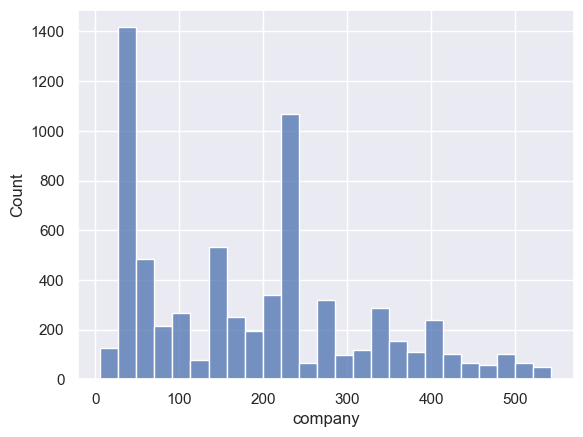

In [282]:
sns.histplot(x='company',data=df)


In [278]:
df['company'].value_counts(normalize=True)*100


<Figure size 640x480 with 0 Axes>

Company Feature Analysis — Summary

The `company` variable represents corporate entities or organizations associated with hotel bookings. The distribution shows that reservations are highly concentrated among a small number of companies, with **Company 40 (~13.6%)** and **Company 223 (~11.5%)** contributing a substantial share of corporate-linked bookings.

Beyond the top companies, booking frequencies decline sharply across a large number of low-frequency entities, resulting in a highly right-skewed and high-cardinality distribution. This suggests that while a few organizations generate significant booking volume, most companies contribute only occasional reservations.

Key Patterns & Insights

* Corporate bookings are concentrated among a limited number of companies.
* A long-tail distribution exists across hundreds of low-frequency corporate entities.
* Strong imbalance indicates unequal contribution to hotel demand.
* Certain companies likely represent recurring business partnerships or enterprise travel accounts.

Business Insights

These patterns suggest that:

* a small number of corporate clients may contribute disproportionately to stable occupancy,
* maintaining relationships with high-volume companies could be strategically important,
* and corporate partnerships may provide predictable booking demand compared to leisure travel.

The concentration pattern also indicates opportunities for:

* corporate loyalty programs,
* enterprise pricing strategies,
* and partnership-based revenue optimization.

Modeling Implications

The `company` feature may contain useful signals related to:

* business-travel behavior,
* booking reliability,
* and cancellation tendencies.

However, its high cardinality may create modeling complexity. Potential preprocessing strategies include:

* frequency encoding,
* target encoding,
* grouping rare companies into an `Other` category,
* or focusing on major corporate clients only.

The feature may become particularly informative when combined with:

* `market_segment`
* `distribution_channel`
* `ADR`
* `is_canceled`
* `lead_time`


### days_in_waiting_list

In [139]:
df['days_in_waiting_list'].unique()

array([  0,  50,  47,  65, 122,  75, 101, 150, 125,  14,  60,  34, 100,
        22, 121,  61,  39,   5,   1,   8, 107,  43,  52,   2,  11, 142,
       116,  13,  44,  97,  83,   4, 113,  18,  20, 185,  93, 109,   6,
        37, 105, 154,  64,  99,  38,  48,  33,  77,  21,  80,  59,  40,
        58,  89,  53,  49,  69,  87,  91,  57, 111,  79,  98,  85,  63,
        15,   3,  41, 224,  31,  56, 187, 176,  71,  55,  96, 236, 259,
       207, 215, 160, 120,  30,  32,  27,  62,  24, 108, 147, 379,  70,
        35, 178, 330, 223, 174, 162, 391,  68, 193,  10,  76,  16,  28,
         9, 165,  17,  25,  46,   7,  84, 175, 183,  23, 117,  12,  54,
        26,  73,  45,  19,  42,  72,  81,  92,  74, 167,  36], dtype=int64)

<Axes: xlabel='days_in_waiting_list', ylabel='Count'>

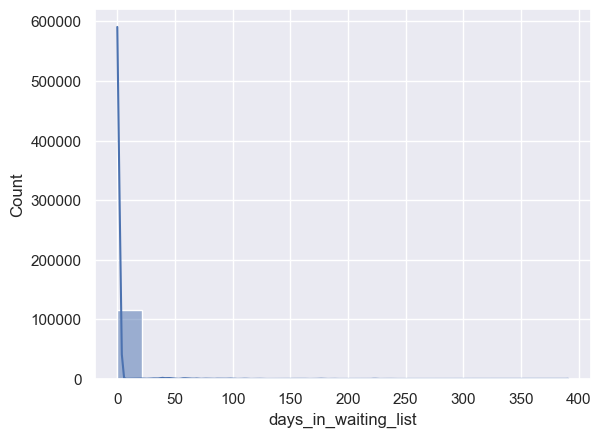

In [140]:
sns.histplot(x='days_in_waiting_list',data=df,kde=True)

In [141]:
df['days_in_waiting_list'].value_counts(normalize=True)*100

days_in_waiting_list
0      96.902588
39      0.190133
58      0.137365
44      0.118100
31      0.106374
         ...    
116     0.000838
109     0.000838
37      0.000838
89      0.000838
36      0.000838
Name: proportion, Length: 128, dtype: float64

Days in Waiting List Analysis — Summary

The `days_in_waiting_list` variable shows that the overwhelming majority of bookings (**~96.9%**) were not placed on a waiting list, indicating that most reservations were either confirmed immediately or processed without capacity constraints.

Only a very small fraction of bookings experienced waiting periods, with scattered values across multiple durations such as 31, 39, 44, and 58 days. The distribution is therefore extremely right-skewed, with a long tail of rare waiting-list cases.

Key Patterns & Insights

* Most bookings bypass the waiting-list process entirely.
* Waiting-list occurrences are exceptionally rare.
* The distribution contains sparse long-tail waiting durations.
* Capacity-related booking delays appear limited overall.

Business Insights

These patterns suggest that:

* hotels generally maintain sufficient room availability,
* overbooking or inventory shortages are not frequent operational issues,
* and waiting-list management likely affects only a niche subset of reservations.

Rare long waiting periods may reflect:

* peak-season demand,
* high-demand room categories,
* or group/corporate reservation complexities.

Modeling Implications

The standalone predictive power of `days_in_waiting_list` may be limited due to extreme imbalance. However, it could still provide useful operational signals when combined with:

* `lead_time`
* `reserved_room_type`
* `hotel`
* `is_canceled`

Potential feature engineering opportunities include:

* waiting-list flag creation,
* peak-demand identification,
* and delayed-confirmation risk analysis.


In [143]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')

### customer_type

In [145]:
df['customer_type'].unique()

array(['Transient', 'Contract', 'Transient-Party', 'Group'], dtype=object)

<Axes: xlabel='customer_type', ylabel='count'>

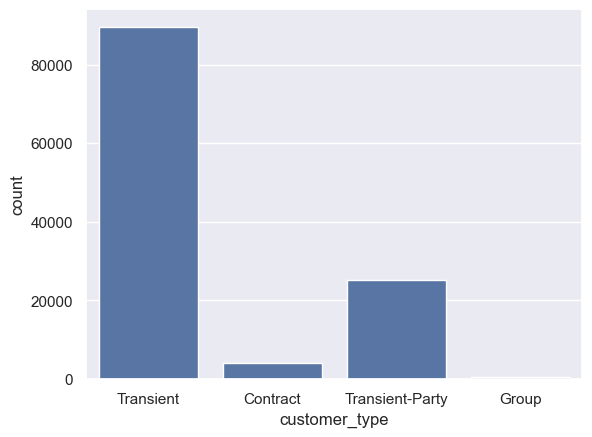

In [286]:
sns.countplot(x='customer_type',data=df)


In [147]:
df['customer_type'].value_counts(normalize=True)*100

customer_type
Transient          75.059050
Transient-Party    21.043638
Contract            3.414021
Group               0.483290
Name: proportion, dtype: float64

Customer Type Analysis — Summary

The `customer_type` variable shows that **Transient customers (~75.1%)** dominate hotel bookings, indicating that most reservations come from short-term individual travelers such as tourists or business guests booking independently.

**Transient-Party customers (~21%)** form a significant secondary segment, representing travelers booking as part of informal groups or linked reservations without long-term contractual arrangements. In contrast, **Contract (~3.4%)** and **Group (~0.5%)** customers contribute only a small share of total bookings.

The distribution suggests that hotel demand is primarily driven by flexible, short-term travel behavior rather than stable contractual or large-group arrangements.

Key Patterns & Insights

* Independent transient travelers dominate the dataset.
* Informal group-linked bookings form a meaningful secondary segment.
* Contract-based and organized group bookings are relatively limited.
* Customer behavior appears heavily tourism and short-stay oriented.

Business Insights

These patterns suggest that:

* hotel revenue depends largely on dynamic short-term demand,
* occupancy may be more sensitive to seasonality and travel trends,
* and customer retention through long-term contracts appears limited.

The dominance of transient customers also aligns with earlier findings involving:

* OTA-heavy booking behavior,
* low repeat guest percentages,
* and flexible deposit policies.

Modeling Implications

The `customer_type` feature may provide useful behavioral signals when analyzed with:

* `is_canceled`
* `lead_time`
* `market_segment`
* `ADR`
* `distribution_channel`

Potential feature engineering opportunities include:

* transient vs stable customer classification,
* group-travel behavioral analysis,
* and customer-risk segmentation.


### adr

In [150]:
df['adr'].unique()

array([  0.  ,  75.  ,  98.  , ..., 266.75, 209.25, 157.71])

<Axes: xlabel='adr', ylabel='Count'>

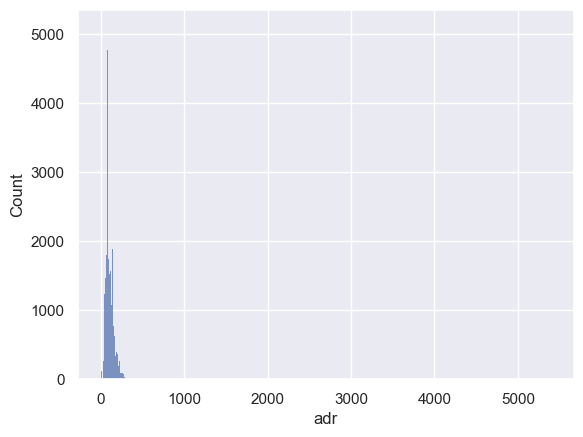

In [151]:
sns.histplot(x='adr',data=df)

In [152]:
df['adr'].value_counts(normalize=True)*100

adr
62.00     3.144317
75.00     2.274060
90.00     2.071363
65.00     2.025295
0.00      1.640841
            ...   
89.43     0.000838
63.07     0.000838
55.69     0.000838
49.51     0.000838
157.71    0.000838
Name: proportion, Length: 8879, dtype: float64

ADR (Average Daily Rate) Analysis — Summary

The `adr` variable represents the average daily room price paid per booking and exhibits a highly continuous, high-cardinality distribution with substantial pricing variability across reservations. Common ADR values cluster around moderate price ranges such as **62, 65, 75, and 90**, suggesting that most bookings fall within standard mid-range pricing tiers.

The presence of an ADR value of **0** indicates a subset of bookings with no room revenue, which may correspond to:

* complimentary stays,
* staff/partner reservations,
* canceled bookings,
* or data-entry inconsistencies.

The distribution appears strongly right-skewed, with a long tail of higher-priced reservations reflecting premium room categories, peak-season pricing, luxury stays, or dynamic pricing strategies.

Key Patterns & Insights

* Most bookings fall within moderate pricing ranges.
* ADR exhibits high variability and strong pricing dispersion.
* Presence of zero-value ADRs suggests special-case or non-revenue bookings.
* Long-tail premium pricing behavior exists but is relatively rare.

Business Insights

These patterns suggest that:

* hotels likely use dynamic pricing based on seasonality, occupancy, and room demand,
* standard room categories drive the majority of revenue,
* and premium pricing opportunities exist during high-demand periods.

ADR behavior may also vary significantly across:

* hotel type,
* room category,
* market segment,
* and booking channel.

Modeling Implications

The `adr` feature is likely to be one of the strongest predictive variables in the dataset and may contain valuable signals related to:

* cancellation behavior,
* customer segmentation,
* and revenue optimization.

Potential feature engineering opportunities include:

* ADR bins (`budget`, `mid-range`, `premium`),
* seasonal pricing analysis,
* and occupancy-adjusted revenue metrics.

Because of its skewness and wide range, ADR may also benefit from:

* outlier treatment,
* log transformation,
* or robust scaling during preprocessing.


### required_car_parking_spaces

In [155]:
df['required_car_parking_spaces'].unique()

array([0, 1, 2, 8, 3], dtype=int64)

<Axes: xlabel='required_car_parking_spaces', ylabel='count'>

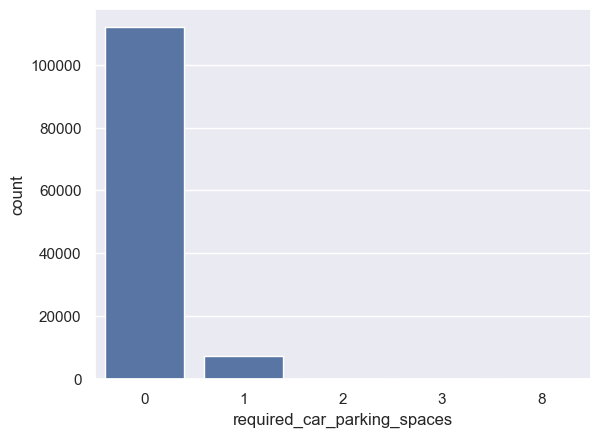

In [156]:
sns.countplot(x='required_car_parking_spaces',data=df)

In [157]:
df['required_car_parking_spaces'].value_counts(normalize=True)*100

required_car_parking_spaces
0    93.788424
1     6.183935
2     0.023453
3     0.002513
8     0.001675
Name: proportion, dtype: float64

Required Car Parking Spaces Analysis — Summary

The `required_car_parking_spaces` variable shows that the vast majority of bookings (**~93.8%**) do not require any parking space, indicating that most guests either do not travel by private vehicle or stay in locations where parking demand is minimal.

A small but notable segment (**~6.2%**) requires exactly one parking space, suggesting a minority of guests traveling by car, likely including domestic tourists or road-trip travelers. Requirements for more than one parking space are extremely rare, with values of 2, 3, and 8 spaces appearing only in negligible proportions and likely representing group bookings or data anomalies.

Key Patterns & Insights

* Most guests do not require parking facilities.
* Single-car demand is a small but meaningful segment.
* Multi-space requirements are extremely rare.
* Distribution is heavily skewed toward zero parking demand.

Business Insights

These patterns suggest that:

* hotels are primarily serving air/rail/OTA-driven travelers rather than private vehicle users,
* parking infrastructure is likely under low continuous pressure,
* and parking demand is concentrated among a niche segment of domestic or road-based tourists.

This feature may also reflect differences between:

* city hotels (low parking demand),
* resort hotels (potentially higher car usage).

Modeling Implications

The `required_car_parking_spaces` feature may be useful when combined with:

* `hotel`
* `country`
* `market_segment`
* `adr`
* `is_canceled`

Potential feature engineering opportunities include:

* parking demand flag (`requires_parking`),
* mobility-based segmentation (car vs non-car travelers),
* and travel-mode inference features.


### total_of_special_requests

In [160]:
df['total_of_special_requests'].unique()

array([0, 1, 3, 2, 4, 5], dtype=int64)

<Axes: xlabel='total_of_special_requests', ylabel='count'>

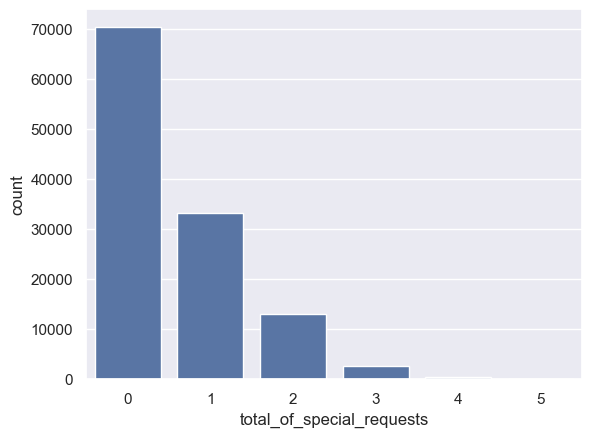

In [290]:
sns.countplot(x='total_of_special_requests',data=df)


In [162]:
df['total_of_special_requests'].value_counts(normalize=True)*100

total_of_special_requests
0    58.897730
1    27.829801
2    10.862719
3     2.091465
4     0.284781
5     0.033504
Name: proportion, dtype: float64

Total Special Requests Analysis — Summary

The `total_of_special_requests` variable shows that the majority of bookings (**~58.9%**) have **no special requests**, indicating that most guests make standard reservations without additional customization needs.

A significant portion of guests (**~27.8%**) make **one special request**, while **~10.9%** make two requests. Higher request counts are rare, with only a small fraction of bookings having 3 or more special requests.

Key Patterns & Insights

* Most guests do not make any special requests.
* One request is the most common level of customization.
* Special request frequency declines sharply after 2 requests.
* High-request bookings (4–5) are rare and form a long tail.

Business Insights

These patterns suggest that:

* most guests prefer standard hotel services with minimal customization,
* a meaningful segment actively engages with the hotel experience (1–2 requests),
* high-request customers may represent special cases such as families, VIP guests, or complex itineraries.

Special requests can also indicate:

* higher customer engagement,
* potentially higher satisfaction needs,
* or more complex travel arrangements.

Modeling Implications

The `total_of_special_requests` feature is likely to be highly predictive for:

* `is_canceled`
* customer satisfaction proxy
* booking commitment level

Potential feature engineering opportunities include:

* no-request vs high-engagement segmentation,
* guest interaction scoring,
* and service-demand intensity features.


In [164]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')

### reservation_status

In [166]:
df['reservation_status'].unique()

array(['Check-Out', 'Canceled', 'No-Show'], dtype=object)

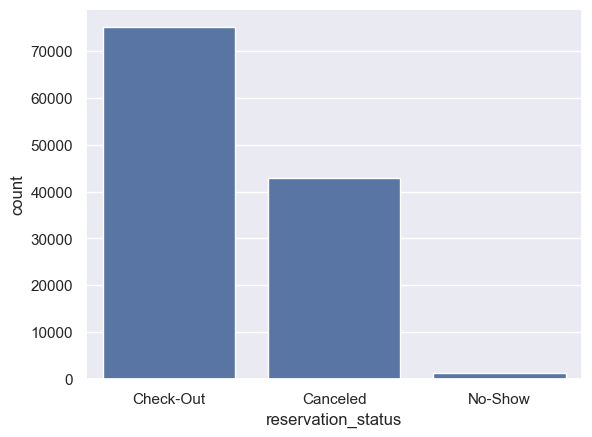

In [292]:
sns.countplot(x='reservation_status',data=df)
plt.savefig(r'D:\Shorya\VScode\hotel booking\images\reservation_status.png')


In [168]:
df['reservation_status'].value_counts(normalize=True)*100

reservation_status
Check-Out    62.958372
Canceled     36.030656
No-Show       1.010972
Name: proportion, dtype: float64

Reservation Status Analysis — Summary

The `reservation_status` variable shows that approximately **63.0%** of bookings result in a **Check-Out**, indicating successful stays completed by guests. However, a significant **36.0% of reservations are Canceled**, highlighting a substantial cancellation rate within the dataset. A small fraction (**~1.0%**) are **No-Shows**, where guests neither cancel in advance nor arrive.

Key Patterns & Insights

* Successful stays (Check-Out) form the majority but not overwhelmingly dominant.
* Cancellations are very high (~36%), indicating strong booking uncertainty.
* No-show cases are rare but operationally relevant.
* Overall demand shows noticeable instability before actual arrival.

Business Insights

These patterns suggest that:

* cancellation management is a critical business challenge for hotels,
* revenue forecasting must account for high booking volatility,
* and policies like deposits, lead-time restrictions, and channel-based pricing are likely important controls.

The presence of a high cancellation rate aligns with earlier findings:

* dominance of OTA bookings,
* flexible deposit types,
* high transient customer base,
* and low repeat guest percentage.

Modeling Implications

The `reservation_status` variable is extremely informative but also **leaky for predictive modeling** if used directly to predict `is_canceled` or final outcomes (since it encodes the outcome itself).

Potential uses include:

* post-hoc analysis (not training feature for leakage-prone models),
* segmentation of booking outcomes,
* and evaluation of operational performance.

Final Insight

The dataset is fundamentally shaped by **high booking uncertainty**, where more than one-third of reservations do not translate into actual stays—making cancellation behavior the central analytical and business focus of the entire EDA.


### reservation_status_date

In [171]:
df['reservation_status_date'].nunique()

926

# Univariate analysis summary

## Hotel Booking Dataset — Univariate Analysis Summary

This univariate analysis reveals a **highly behavior-driven, OTA-dependent hospitality dataset** with strong signals across customer composition, booking behavior, pricing, and cancellation dynamics. Most variables show **skewed distributions, long-tail behavior, and strong class imbalance**, indicating that hotel demand is concentrated in a few dominant patterns rather than evenly distributed.

---

# 1. Customer & Guest Composition Patterns

### Key Observations

* **Adults:** ~75% bookings are 2-adult stays → strong couple-driven demand.
* **Children & Babies:** Extremely low presence (~7% children, <1% babies overall).
* **Customer Type:** ~75% transient customers.
* **Repeated Guests:** Only ~3% repeat customers.
* **Country:** Strong dominance of Portugal (~41%) + Europe-wide concentration.

### Key Insight

The dataset is dominated by **short-term, first-time, leisure-oriented travelers**, with minimal family-heavy or loyalty-driven demand.

### Business Meaning

* Hotels rely more on **new customer acquisition than retention**
* Strong tourism + OTA-driven ecosystem
* Family tourism exists but is secondary

---

# 2. Booking Behavior Patterns

### Key Observations

* **Lead time (from earlier context):** highly skewed → early bookings common
* **Booking changes:** ~85% no changes → stable booking behavior
* **Special requests:** majority have 0–1 requests (~86%)
* **Days in waiting list:** ~97% no waiting time
* **Parking space needs:** ~94% no requirement

### Key Insight

Most bookings are **simple, low-interaction transactions**, with minimal customization or operational friction.

### Business Meaning

* Guests prefer fast, frictionless booking experience
* Limited operational complexity per booking
* Small subset of guests drives most operational variation

---

# 3. Pricing & Revenue Patterns (ADR)

### Key Observations

* Strong clustering around mid-range ADR values
* High variability with long right tail
* Presence of **zero ADR values**
* Clear evidence of dynamic pricing behavior

### Key Insight

Revenue structure is **heavily skewed toward standard pricing tiers**, with occasional premium outliers.

### Business Meaning

* Strong dynamic pricing strategy already in place
* Majority of revenue comes from standard rooms
* Some data quality issues (zero ADR) need attention

---

# 4. Room Allocation Patterns

### Key Observations

* Reserved Room A: ~72%
* Assigned Room A: ~62%
* Significant redistribution across room types D, E, F, G
* Rare premium room usage
* Evidence of upgrades/downgrades

### Key Insight

Hotels actively perform **operational room optimization (reallocation/upgrades)**.

### Business Meaning

* Inventory management plays a key operational role
* Room upgrades likely used for balancing occupancy or guest satisfaction
* Demand concentrated in standard room categories

---

# 5. Cancellation & Booking Risk Patterns

### Key Observations

* Overall cancellation rate: ~36%
* No-show ~1%
* Deposit type: ~88% no deposit
* Previous cancellations exist but concentrated in small risky group

### Key Insight

The dataset has a **high cancellation risk environment**, strongly influenced by booking flexibility.

### Business Meaning

* Flexible booking policies increase cancellation exposure
* A small subset of customers drives disproportionate risk
* Deposit type is a key control variable

---

# 6. Channel & Distribution Structure

### Key Observations

* Market Segment:

  * Online TA ~47%
  * Offline TA/TO ~20%
* Distribution Channel:

  * TA/TO ~82%
* Agents & Companies: highly concentrated long-tail distributions

### Key Insight

The hotel ecosystem is **heavily intermediary-driven**, especially OTA-based.

### Business Meaning

* Strong dependency on third-party platforms
* Revenue likely commission-sensitive
* A few agents/companies dominate booking volume

---

# 7. Most Important Features in Dataset

Based on distribution strength, business relevance, and predictive potential:

### High-Impact Features

* `lead_time`
* `adr`
* `market_segment`
* `distribution_channel`
* `deposit_type`
* `total_of_special_requests`
* `is_repeated_guest`
* `previous_cancellations`

### Structural / Operational Features

* `reserved_room_type`
* `assigned_room_type`
* `booking_changes`
* `customer_type`
* `agent`
* `company`

### Context Features

* `country`
* `hotel`
* `meal`

---

# 8. Key Global Insights (Big Picture)

### 1. OTA-Driven Business Model

Most bookings flow through **Online Travel Agencies and agents**, not direct channels.

### 2. High Cancellation Environment

~36% cancellation rate → core business challenge.

### 3. Short-Term, Low-Commitment Customers

Transient users dominate with minimal loyalty and low repeat behavior.

### 4. Standard Room & Mid-Price Dominance

Demand is concentrated in **basic room categories and mid-range pricing**.

### 5. Operational Simplicity per Booking

Most bookings require:

* no changes
* no parking
* no waiting list
* no special requests

---

# 9. Feature Engineering Recommendations

## Customer-Level Features

* `total_guests = adults + children + babies`
* `is_family`
* `is_solo_traveler`
* `guest_type_cluster`

## Behavioral Features

* `booking_stability = booking_changes`
* `risk_score = previous_cancellations`
* `loyalty_score = previous_bookings_not_canceled`

## Pricing Features

* `adr_category (low/mid/high)`
* `log_adr`
* `seasonal_adr_bucket`

## Channel Features

* `is_ota_booking`
* `is_direct_booking`
* `high_dependency_agent_flag`

## Operational Features

* `room_change_flag (reserved != assigned)`
* `upgrade_indicator`
* `parking_required_flag`

## Engagement Features

* `special_request_intensity`
* `waiting_list_flag`

---

# Final Takeaway

This dataset represents a **highly dynamic, OTA-driven hospitality system dominated by transient, short-term customers with high cancellation risk and low loyalty.**

The strongest predictive signals are not isolated variables but **interaction-based behavioral patterns**, especially around:

* booking flexibility
* channel dependency
* pricing sensitivity
* customer reliability history

